# Исследование объявлений о продаже квартир

**Описание и цель проекта**: В качестве исходных данных прелоставлены данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Необходимо определить рыночную стоимость объектов недвижимости, провести исследовательский анализ данных и установить параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**Описание данных**:

airports_nearest — расстояние до ближайшего аэропорта в метрах (м)

balcony — число балконов

ceiling_height — высота потолков (м)

cityCenters_nearest — расстояние до центра города (м)

days_exposition — сколько дней было размещено объявление (от публикации до снятия)

first_day_exposition — дата публикации

floor — этаж

floors_total — всего этажей в доме

is_apartment — апартаменты (булев тип)

kitchen_area — площадь кухни в квадратных метрах (м²)

last_price — цена на момент снятия с публикации

living_area — жилая площадь в квадратных метрах (м²)

locality_name — название населённого пункта

open_plan — свободная планировка (булев тип)

parks_around3000 — число парков в радиусе 3 км

parks_nearest — расстояние до ближайшего парка (м)

ponds_around3000 — число водоёмов в радиусе 3 км

ponds_nearest — расстояние до ближайшего водоёма (м)

rooms — число комнат

studio — квартира-студия (булев тип)

total_area — общая площадь квартиры в квадратных метрах (м²)

total_images — число фотографий квартиры в объявлении

**План работы:**
1. Изучить предоставленные данные.

2. Выполнить предобработку данных 

3. Добавить в датафрейм новые столбцы со следующими параметрами:
<br> - цена одного квадратного метра);
<br> - день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
<br> - месяц публикации объявления;
<br> - год публикации объявления;
<br> - тип этажа квартиры (значения — «первый», «последний», «другой»);
<br> - расстояние до центра города в километрах.

4. Провести исследовательский анализ данных по следующим пунктам:
<br>4.1. Изучить перечисленные ниже параметры объектов и построить отдельные гистограммы для каждого из этих параметров. В некоторых параметрах встречаются редкие и выбивающиеся значения.  Если природа аномалии понятна и данные действительно искажены, то необходимо восстановить корректное значение. В противном случае удалить редкие и выбивающиеся значения.
<br>Список параметров:
<br> - общая площадь;
<br> - жилая площадь;
<br> - площадь кухни;
<br> - цена объекта;
<br> - количество комнат;
<br> - высота потолков;
<br> - тип этажа квартиры («первый», «последний», «другой»);
<br> - общее количество этажей в доме;
<br> - расстояние до центра города в метрах;
<br> - расстояние до ближайшего парка
<br>4.2. Изучить, как быстро продавались квартиры (столбец days_exposition). 
<br> - построить гистограмму.
<br> - посчитать среднее и медиану.
<br> - определить сколько времени обычно занимает продажа. Какие продажи можно считать быстрыми, а какие — необычно долгими? 
<br>4.3. Определить факторы, которые больше всего влияют на общую стоимость объекта.
<br>Изучите, зависит ли цена от:
<br> - общей площади;
<br> - жилой площади;
<br> - площади кухни;
<br> - количества комнат;
<br> - этажа, на котором расположена квартира (первый, последний, другой);
<br> - даты размещения (день недели, месяц, год).
<br> - Построить графики, которые покажут зависимость цены от указанных выше параметров. 
<br>4.4. Посчитать среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений.
<br>Выделить населённые пункты с самой высокой и низкой стоимостью квадратного метра.
<br>4.5. Выделить квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислить их среднюю стоимость на разном удалении от центра. Учесть каждый километр расстояния: узнать среднюю цену квартир в одном километре от центра, в двух и так далее. Описать, как стоимость объектов зависит от расстояния до центра города — построить график изменения средней цены для каждого километра от центра Петербурга.
5. Описать полученные результаты и зафиксируйте итоговый вывод проведённого исследования.

### Общая информация о датафрейме

In [1]:
import pandas as pd
# импортируем библиотеку pandas 
import numpy as np
# импортируем библиотеку numpy

In [2]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
data.head() #открываем файл с данными и выводим первые 5 строк, чтобы увидеть структуру датафрейма и проверить 
#что датафрейм выводится удобочитаемо

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [3]:
data.info() # выводим общую информацию о датафрейме, с целью анализа типов данных и количества значений в столбцах

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

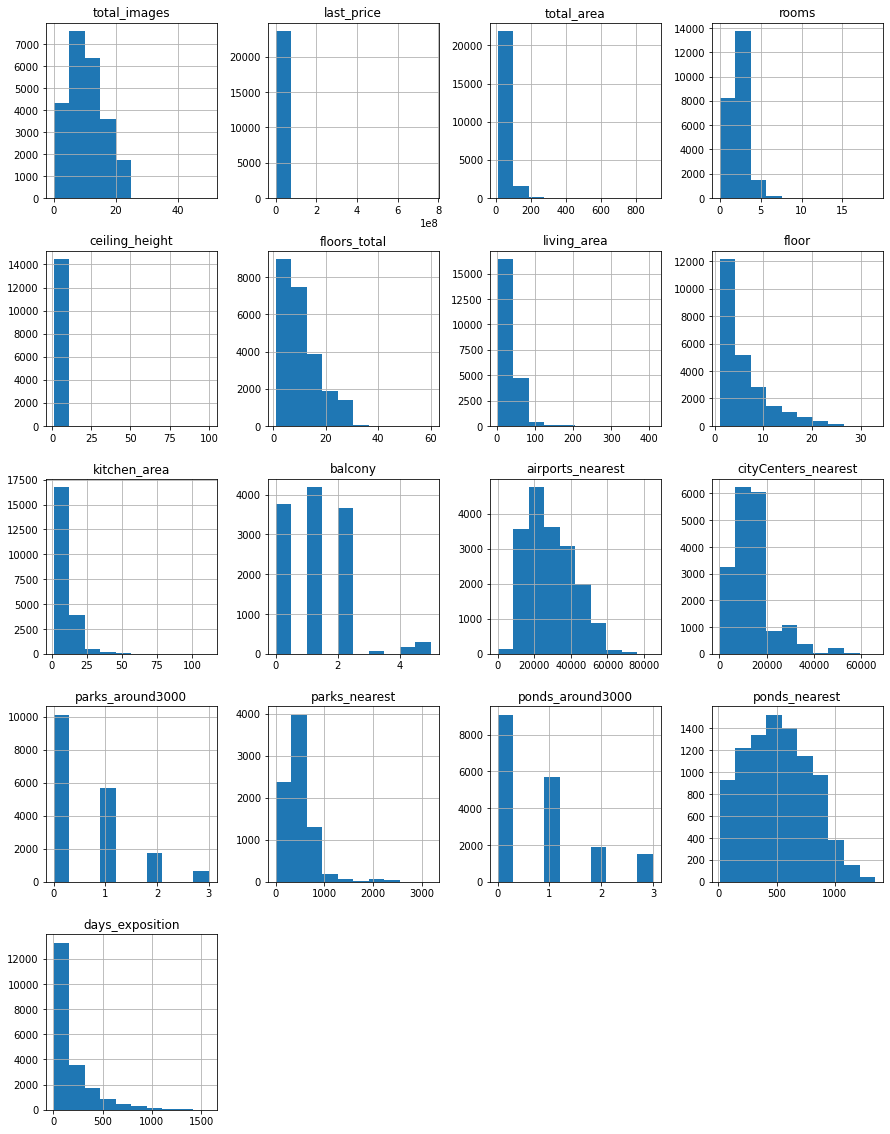

In [4]:
data.hist(figsize=(15, 20));
# построим гистограмму распределения значений для всех числовых столбцов датафрейма

**Вывод**: в представленных в датафрейме данных, имеются множественные пропуски в столбцах ceiling_height, living_area, is_apartment, kitchen_area, balcony, airports_nearest, cityCenters_nearest, parks_around3000, parks_nearest, ponds_around3000, ponds_nearest, days_exposition. Необходимо проанализировать данные пропуски и попытаться восстановить пропущенные значения.
Анализ распределения значений на гистограммах, показывает наличие длинных "хвостов" в большинстве столбцов датафрейма. Необходимо проанализировать природу возникновения данных выбросов, чтобы отсечь ошибочные значения, если таковые имеются.  

### Предобработка данных

#### Обработка пропусков

In [5]:
data.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

Проведем анализ названия столбцов. Столбцы 'cityCenters_nearest', 'parks_around3000', 'ponds_around3000' приведем в соответствие "змеиному" регистру   

In [6]:
data = (data.rename(columns={'cityCenters_nearest': 'city_centers_nearest', 'parks_around3000':'parks_around_3000', 
                             'ponds_around3000': 'ponds_around_3000'}))

In [7]:
data.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'city_centers_nearest',
       'parks_around_3000', 'parks_nearest', 'ponds_around_3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

Проверили что замена названий столцов выполнена

Определим какие столбцы имеют пропуски, а также опрделим количество данных пропусков:

In [8]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around_3000        5518
parks_nearest           15620
ponds_around_3000        5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [9]:
# check
# пропущенные значения бары

def pass_value_barh(df):
    try:
        (
            (df.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (19,6), rot = -5, legend = False, fontsize = 16)
            .set_title('Пример' + "\n", fontsize = 22, color = 'SteelBlue')    
        );    
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')

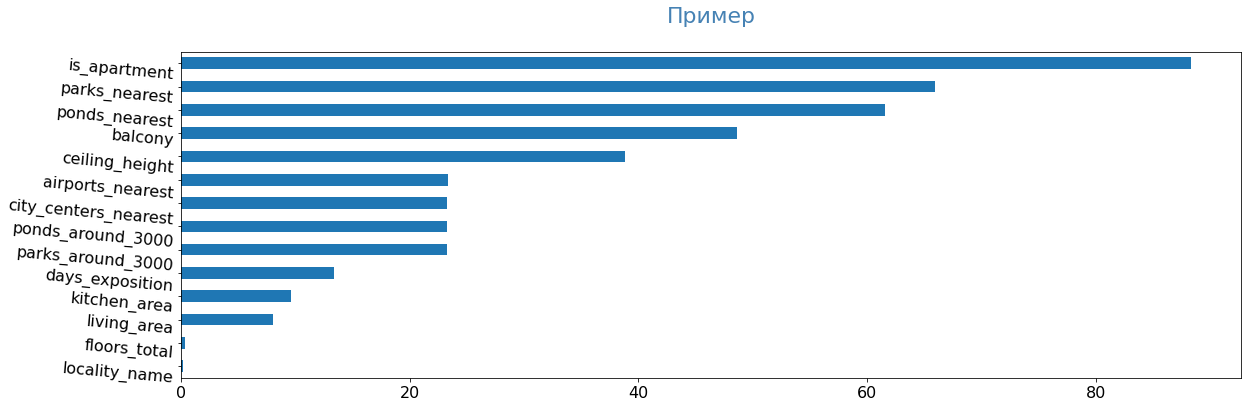

In [10]:
pass_value_barh(data)

Пропущенные значения в столбце living_area восстановим следующим образом:
Найдем среднее отношение общей площади (total_area) к жилой площади (living_area).Если мы сложим все значения total_area и разделим их на сумму living_area из текущего датафрейма, то получим неверный коэффициент отношения данных площадей, т.к. в total_area пропусков нет, в то время как в living_area они есть.
Поэтому создадим отдельный датафрейм data_for_ratio, состоящий из строк, в которых значения столбца living_area определены.
Из этого датафрейма найдем коэффициент отношения жилой площади к общей площади объекта - ratio_living_area_to_total.
Сделаем срез датафрейма по пропускам в столбце living_area и заполним их значением общей площади данного объекта умноженного на коэффициент - ratio_living_area_to_total.Пропуски в данном столбце образовались либо по причине того, что значения не указаны пользователем, либо ввиду некорректной выгрузки/технической ошибки.

Введем временную переменную data_temporary на которой проведем анализ пропусков, для того чтобы у нас всегда была возможность вернуться к сырым данным data, а в этой переменной показать какие то неудачные попытки обработать данные

In [11]:
data_temporary = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

In [12]:
data_temporary = (data_temporary.rename(columns={'cityCenters_nearest': 'city_centers_nearest', 
                'parks_around3000':'parks_around_3000', 'ponds_around3000': 'ponds_around_3000'}))

In [13]:
data_temporary['living_area'].describe()

count    21796.000000
mean        34.457852
std         22.030445
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

In [14]:
data_for_ratio = data_temporary[~data_temporary['living_area'].isna()]
ratio_living_area_to_total = data_for_ratio['living_area'].sum()/data_for_ratio['total_area'].sum()
data_temporary.loc[data_temporary['living_area'].isna(), 'living_area'] = \
ratio_living_area_to_total*data_temporary['total_area']
data_temporary['living_area'] = round(data_temporary['living_area'], 1)

In [17]:
data_temporary['living_area'].describe()

count    23699.000000
mean        34.606654
std         22.365798
min          2.000000
25%         19.000000
50%         30.000000
75%         42.100000
max        409.700000
Name: living_area, dtype: float64

Анализ статистик выполненных до и после восстановления значений, показывает незначительное увеличение стандартного отклонения, среднего значения,  увеличение первого и уменьшение третьего квартилей. Можем принять выполненную замену к дальнейшему анализу.

Пропущенные значения в столбце kitchen_area восстановим аналогично значениям столбца living_area - через коэффициент среднего отношения площади кухни к общей площади объекта. Пропуски образовались либо по причине того, что значения не указаны пользователем (случайно или с целью скрыть реальную площадь кухни), либо ввиду некорректной выгрузки/технической ошибки.

In [18]:
data_temporary['kitchen_area'].describe()

count    21421.000000
mean        10.569807
std          5.905438
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

In [19]:
data_for_ratio2 = data_temporary[~data_temporary['kitchen_area'].isna()]
ratio_kitchen_area_to_total = data_for_ratio2['kitchen_area'].sum()/data_for_ratio2['total_area'].sum()
data_temporary.loc[data_temporary['kitchen_area'].isna(), 'kitchen_area'] =\
ratio_kitchen_area_to_total*data_temporary['total_area']
data_temporary['kitchen_area'] = round(data_temporary['kitchen_area'], 1)

In [23]:
data_temporary['kitchen_area'].describe()

count    23699.000000
mean        10.499848
std          6.035371
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

Анализ статистик выполненных до и после восстановления значений, показывает незначительное увеличение стандартного отклонения и  уменьшение среднего значения и медианы. Можем принять выполненную замену к дальнейшему анализу.

Проверим что выполненные искуственные замены не привели к нарушению логики, что сумма жилой площади и кухни не превышает значение общей площади. Чтобы учесть в данной проверке наличие коридоров, балконов и санузлов, которые не входят ни в жилую площадь, ни в площадь кухни, отведем на них 10% от общей площади, применив к ней коэффициент 0,9.

In [24]:
len(data_temporary.query('total_area*0.9 <= (living_area + kitchen_area)'))

661

In [25]:
len(data.query('total_area*0.9 <= (living_area + kitchen_area)'))

475

661 строка после обработки значений не прошли проверку по условию соотношения площадей. Также 475 строк не проходит такую проверку на сырых данных. Это достаточно большое значение, по отношению к обшему количеству в 2717 пропусков. Удалим все эти данные (в том числе и "сырые"), так как они могут быть некорректны. Введем новую переменную data_clear, чтобы результаты анализа выше, можно было оставить, но они не оказывали бы влияние на дальнейшие вычисления

In [26]:
# check
import matplotlib.pyplot as plt

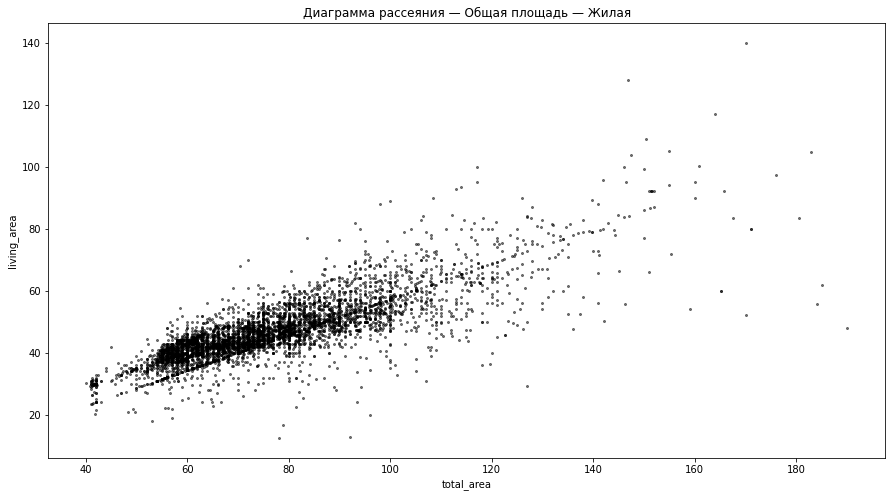

In [27]:
# check
data_temporary[data_temporary['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(kind='scatter',
        y='living_area' , x='total_area', alpha=0.5, subplots=True, figsize=(15,8), c = 'black', s = 4)
plt.title('Диаграмма рассеяния — Общая площадь — Жилая');

In [28]:
data_clear = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

In [29]:
data_clear = (data_clear.rename(columns={'cityCenters_nearest': 'city_centers_nearest', 
                'parks_around3000':'parks_around_3000', 'ponds_around3000': 'ponds_around_3000'}))

In [30]:
data_clear = data_clear[(~data_clear['living_area'].isna()) & (~data_clear['kitchen_area'].isna())]

Пропущенные значения floors_total и locality_name удалим, т.к. для этих данных нет адекватной замены, а количество пропусков по этим столбцам небольшое (86 и 49 соответственно). Пропуски образовались либо по причине того, что значения не указаны пользователем, либо ввиду некорректной выгрузки/технической ошибки.

In [31]:
data_clear = data_clear.loc[(~data_clear['floors_total'].isna()) & (~data_clear['locality_name'].isna())]

Пропущенные значения в столбце ceiling_height заменим на медианное значение данного столбца, чтобы исключить влияние выбросов, присутствующих на гистограмме. Пропуски образовались либо по причине того, что значения не указаны пользователем (случайно или с целью скрыть реальную высоту потолка), либо ввиду некорректной выгрузки/технической ошибки.

In [32]:
data_clear['ceiling_height'].describe()

count    13318.000000
mean         2.764869
std          1.246797
min          1.000000
25%          2.510000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64

In [33]:
data_clear['ceiling_height'] = data_clear['ceiling_height'].fillna(data_clear['ceiling_height'].median())

In [34]:
data_clear['ceiling_height'].describe()

count    20905.000000
mean         2.723180
std          0.996672
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

Пропущенные значения в столбце is_apartment оставим как есть, т.к. для этих данных нет адекватной замены, а значений пропущено очень много (20924).

Пропуски в столбце balcony заполним значением 0, т.к. пропуски при заполнении данного параметра, скорее всего связан с отсутствием балкона

In [35]:
data_clear['balcony'] = data_clear['balcony'].fillna(0)

Пропущенные значения в столбцах locality_name, airports_nearest, city_centers_nearest, parks_around_3000, parks_nearest, days_exposition оставим как есть, т.к. для этих данных нет адекватной замены. Все данные, кроме данных в столбце days_exposition вычисляются на основании геопозиции объекта. Пропуски в данных столбцах могут быть связаны с отсутсвием парков, прудов и аэропортов на расстоянии 3км от объекта, с технической ошибкой определения геопозиции, либо непредоставлением точного адреса владельцем объекта. Пропуски в days_exposition скорее всего являются ошибкой выгрузки, т.к. не зависят от информации, предоставленной владельцем объекта.

Проверим что для всех столбцов, в которых мы выполняли замены, пропуски исчезли:

In [36]:
data_clear.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment            18380
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         4665
city_centers_nearest     4644
parks_around_3000        4643
parks_nearest           13664
ponds_around_3000        4643
ponds_nearest           12846
days_exposition          2885
dtype: int64

Как мы видим, те пропуски которые мы обрабатывали исчезли, можно двигаться дальше

#### Преобразование типов данных

*Проанализируем типы данных в столбцах и выполним преобразования в отдельных столбцах при необходимости*

In [37]:
data_clear.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20905 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          20905 non-null  int64  
 1   last_price            20905 non-null  float64
 2   total_area            20905 non-null  float64
 3   first_day_exposition  20905 non-null  object 
 4   rooms                 20905 non-null  int64  
 5   ceiling_height        20905 non-null  float64
 6   floors_total          20905 non-null  float64
 7   living_area           20905 non-null  float64
 8   floor                 20905 non-null  int64  
 9   is_apartment          2525 non-null   object 
 10  studio                20905 non-null  bool   
 11  open_plan             20905 non-null  bool   
 12  kitchen_area          20905 non-null  float64
 13  balcony               20905 non-null  float64
 14  locality_name         20905 non-null  object 
 15  airports_nearest   

Значения в столбцах parks_around_3000, ponds_around_3000, days_exposition имеют тип данных float64. Т.к. значения в данных столбцах это целые числа по определению, было бы логично преобразовать их в тип данных int64. Однако оставленные нами пропуски в данных столбцах, не позволят это сделать. 

Столбцы balcony и floors_total  после обработки не имеют пропусков, поэтому преобразование в int64 можем выполнить для всех значений данных столбцов

In [38]:
data_clear['balcony'] = data_clear['balcony'].astype('int')

In [39]:
data_clear['floors_total'] = data_clear['floors_total'].astype('int')

В столбце first_day_exposition выполним преобразовние из типа object в тип datetime для двльнейшей возможности работы с данным столбцом в формате даты/времени.

In [40]:
data_clear['first_day_exposition'] = pd.to_datetime(data_clear['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

Проверим что наши преобразования выполнены:

In [41]:
data_clear.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20905 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          20905 non-null  int64         
 1   last_price            20905 non-null  float64       
 2   total_area            20905 non-null  float64       
 3   first_day_exposition  20905 non-null  datetime64[ns]
 4   rooms                 20905 non-null  int64         
 5   ceiling_height        20905 non-null  float64       
 6   floors_total          20905 non-null  int64         
 7   living_area           20905 non-null  float64       
 8   floor                 20905 non-null  int64         
 9   is_apartment          2525 non-null   object        
 10  studio                20905 non-null  bool          
 11  open_plan             20905 non-null  bool          
 12  kitchen_area          20905 non-null  float64       
 13  balcony         

#### Обработка дубликатов

Проверим датафрейм на наличие явных дубликатов:

In [42]:
data_clear.duplicated().sum()

0

Проверим датафрейм на наличие неявных дубликатов в названиях населенных пунктов:

In [43]:
data_clear['locality_name'] = (
    data_clear['locality_name']
         .str.replace('ё', 'е')
         .str.replace('городской поселок', 'поселок')
         .str.replace('поселок городского типа', 'поселок')
         .str.replace('коттеджный поселок', 'поселок')
         .str.replace('поселок при железнодорожной станции', 'поселок')
         .str.replace('поселок станции', 'поселок')
         .str.replace('садоводческое некоммерческое товарищество', 'садовое товарищество') 
         .str.replace('Никольское', 'село Никольское') 
         .str.replace('деревня Кудрово', 'Кудрово')
    )       

In [44]:
data_clear.sort_values(by='locality_name')['locality_name'].unique()

array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Новая Ладога',
       'Отрадное', 'Павловск', 'Петергоф', 'Пикалево', 'Подпорожье',
       'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург', 'Светогорск',
       'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор', 'Сясьстрой',
       'Тихвин', 'Тосно', 'Шлиссельбург', 'деревня Агалатово',
       'деревня Аро', 'деревня Батово', 'деревня Бегуницы',
       'деревня Белогорка', 'деревня Большая Вруда',
       'деревня Большая Пустомержа', 'деревня Большие Колпаны',
       'деревня Большое Рейзино', 'деревня Большой Сабск', 'деревня Бор',
       'деревня Борисова Грива', 'деревня Ваганово', 'деревня Вартемяги',
       'деревня Выскатка', 'деревня Гарболово', 'деревня Глинк

Наименование населенного пункта "деревня Кудрово" переименован в "Кудрово",  т.к. в 2018 году  деревне Кудрово присвоен статус города

После обработки неявных дубликатов, выполним повторную проверку на явные дубликаты:

In [45]:
data_clear.duplicated().sum()

0

Явные дубликаты не появились

Проверим наличие явных дубликатов по сумме ключевых параметров: 

In [46]:
data_clear.duplicated(['total_area', 'rooms', 'floors_total', 'floor', 'locality_name', 
                                   'city_centers_nearest']).sum()

160

In [47]:
(data_clear[data_clear.duplicated(subset=['total_area', 'rooms', 'floors_total', 'floor', 'locality_name', 
                                   'city_centers_nearest'], keep='first')]).sort_values('locality_name')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition
7489,12,1700000.0,36.0,2016-01-28,1,2.65,5,17.3,3,NaN,...,8.7,1,Волосово,NaN,NaN,NaN,NaN,NaN,NaN,888.0
15180,5,1800000.0,36.0,2017-12-15,1,2.55,5,17.0,3,NaN,...,8.3,2,Волосово,NaN,NaN,NaN,NaN,NaN,NaN,94.0
20336,10,1650000.0,36.0,2018-03-13,1,2.65,5,17.2,3,NaN,...,8.3,0,Волосово,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14804,5,1350000.0,45.0,2017-11-21,2,2.52,5,35.0,5,NaN,...,6.0,0,Волхов,NaN,NaN,NaN,NaN,NaN,NaN,20.0
23276,5,1900000.0,60.0,2017-11-07,3,2.65,5,44.0,2,NaN,...,7.0,0,Волхов,NaN,NaN,NaN,NaN,NaN,NaN,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18131,12,4200000.0,74.3,2018-09-24,3,2.70,3,48.5,3,NaN,...,8.3,5,поселок Углово,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10617,19,2200000.0,68.3,2019-04-11,3,2.50,5,48.6,2,NaN,...,6.3,1,поселок Цвелодубово,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8869,6,2480000.0,33.5,2018-07-11,1,2.55,6,17.0,3,NaN,...,9.5,0,поселок Шушары,18363.0,24165.0,0.0,NaN,0.0,NaN,32.0
20476,8,3564000.0,53.0,2018-10-17,2,2.65,12,28.0,8,NaN,...,12.0,0,поселок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,45.0


In [48]:
(data_clear[data_clear.duplicated(subset=['total_area', 'rooms', 'floors_total', 'floor', 'locality_name', 
                                   'city_centers_nearest'], keep='last')]).sort_values('locality_name')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition
432,12,1490000.0,36.0,2018-09-10,1,2.50,5,17.1,3,NaN,...,8.4,2,Волосово,NaN,NaN,NaN,NaN,NaN,NaN,23.0
15180,5,1800000.0,36.0,2017-12-15,1,2.55,5,17.0,3,NaN,...,8.3,2,Волосово,NaN,NaN,NaN,NaN,NaN,NaN,94.0
7489,12,1700000.0,36.0,2016-01-28,1,2.65,5,17.3,3,NaN,...,8.7,1,Волосово,NaN,NaN,NaN,NaN,NaN,NaN,888.0
8361,4,1250000.0,30.0,2017-06-18,1,2.50,5,16.0,4,NaN,...,6.0,0,Волхов,NaN,NaN,NaN,NaN,NaN,NaN,324.0
7836,5,1900000.0,60.0,2017-05-30,3,2.65,5,38.0,2,NaN,...,8.0,0,Волхов,NaN,NaN,NaN,NaN,NaN,NaN,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10901,12,4250000.0,74.3,2017-04-26,3,2.65,3,48.5,3,NaN,...,8.3,0,поселок Углово,NaN,NaN,NaN,NaN,NaN,NaN,56.0
1223,11,2400000.0,68.3,2017-11-07,3,2.50,5,48.6,2,NaN,...,6.3,1,поселок Цвелодубово,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3992,20,3080000.0,33.5,2019-01-20,1,2.64,6,17.6,3,NaN,...,9.0,0,поселок Шушары,18363.0,24165.0,0.0,NaN,0.0,NaN,NaN
3245,6,2182000.0,35.0,2018-09-27,1,2.65,12,15.0,12,NaN,...,9.3,0,поселок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,45.0


Полученные объекты действительно имеют слишком много похожих параметров, особенно для небольших городов и поселков. Количество таких объектов относительно небольшое, стоит отбросить эти значения, т.к. они все равно дублируются по соновным параметрам. 

In [49]:
data_clear = (data_clear.drop_duplicates(subset=['total_area', 'rooms', 'floors_total', 'floor', 'locality_name', 
                                   'city_centers_nearest']).reset_index(drop=True))

Выполним проверку, удалились ли дубликаты по подмножеству:

In [50]:
data_clear.duplicated(['total_area', 'rooms', 'floors_total', 'floor', 'locality_name', 
                                   'city_centers_nearest']).sum()

0

In [51]:
# check
data.locality_name.nunique()

364

**Вывод:** В рамках предобработки данных проверили стилистическую корректность наименования столбцов: некорректные наименования отредактированы, проанализировали пропуски в данных и восстановили те данные, в которых была такая возможность. Данные по которым возможность восстановления отсутсвовала - были удалены. Пропуски могут быть вызваны как нежеланием владельца указать ту или иную информацию об объекте, так и технической ошибкой/ошибкой при выгрузке. Выполнили проверку датафрейма на явные дубликаты, явные дубликаты - отсутствуют. Выполниили проверку на неявные дубликаты, привели назвния населенных пунктов к единобразию. Выполнили проверку на дубликаты по подмножеству: общая площадь, количество комнат, общая этажность, этаж, наименование населенного пункта, расстояние до центра города. Найдено 160 дубликатов, которые впоследствии были удалены.

### Создание дополнительных столбцов с параметрами для дальнейшего анализа

Добавим в датафрейм столбец, с значением стоимости квадратного метра по каждому объекту и округлим полученные значения до двух знаков после запятой

In [52]:
data_clear['cost_square_meter'] = data_clear['last_price']/data_clear['total_area']
data_clear['cost_square_meter'] = round(data_clear['cost_square_meter'], 2)
data_clear['cost_square_meter'].head()

0    120370.37
1     82920.79
2     92785.71
3    100000.00
4     95065.79
Name: cost_square_meter, dtype: float64

Добавим столбец с днем недели публикации объявления, где: (0 — понедельник, 1 — вторник и так далее):

In [53]:
data_clear['weekday_publication'] = data_clear['first_day_exposition'].dt.weekday
data_clear['weekday_publication'].head()

0    3
1    1
2    3
3    1
4    0
Name: weekday_publication, dtype: int64

Добавим столбец с месяцем публикации объявления, где: (1 — январь, 2 — февраль и так далее):

In [54]:
data_clear['month_publication'] = data_clear['first_day_exposition'].dt.month
data_clear['month_publication'].head()

0     3
1    12
2     8
3     6
4     9
Name: month_publication, dtype: int64

Добавим столбец с годом публикации объявления:

In [55]:
data_clear['year_publication'] = data_clear['first_day_exposition'].dt.year
data_clear['year_publication'].head()

0    2019
1    2018
2    2015
3    2018
4    2018
Name: year_publication, dtype: int64

Добавим столбец floor_type, с информацией о типе этажа, содержащем следующие значения: "первый", "последний", "другой"

Напишем функцию, возвращающую тип этажа

In [56]:
def floor_type_name(row):
    if (row['floor']) == 1:
        res = 'первый'
    elif row['floor'] == row['floors_total'] and row['floor'] > 1:
        res = 'последний'
    elif row['floor'] != row['floors_total'] and row['floor'] > 1:
        res = 'другой'
    return res

Прменим данную функцию для создания нового столбца

In [57]:
data_clear['floor_type'] = data_clear.apply(floor_type_name, axis=1)

Добавим столбец city_centers_nearest_meter с расстоянием до центра города в километрах, округленное до целых чисел

In [58]:
data_clear['city_centers_nearest_kilometer'] = data_clear['city_centers_nearest']/1000
data_clear['city_centers_nearest_kilometer'] = round(data_clear['city_centers_nearest_kilometer'], 0)

**Вывод:** Добавлены столбцы с дополнительной информацией для целей дальнейшего анализа:
*cost_square_meter* - цена одного квадратного метра, округленная до двух знаков после запятой;
*weekday_publication* - день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
*month_publication* - месяц публикации объявления;
*year_publication* - год публикации объявления;
*floor_type* - тип этажа квартиры (значения — «первый», «последний», «другой»);
*city_centers_nearest_kilometer* - расстояние до центра города в километрах.

### Исследовательский анализ данных

#### Анализ значений датафрейма и обработка аномалий

*Рассмотрим гистограмму распределения значений общей площади*

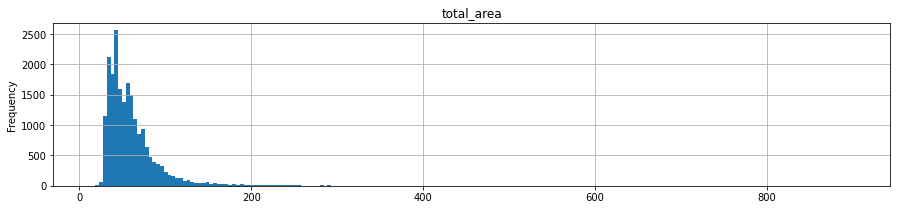

In [59]:
data_clear['total_area'].plot(bins=200, title='total_area', kind='hist', grid=True, figsize=(15,3));

На гистограмме видно пик в районе 50 м2 и длинные хвосты вплоть до 1000 м2. Проанализируем подробнее крайние значения показателей общей площади

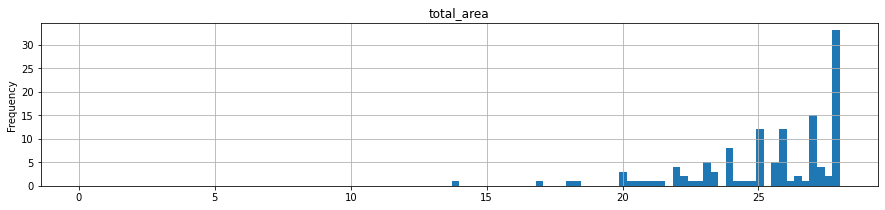

In [60]:
data_clear['total_area'].plot(bins=100, title='total_area', kind='hist', grid=True, figsize=(15,3), range=(0,28));

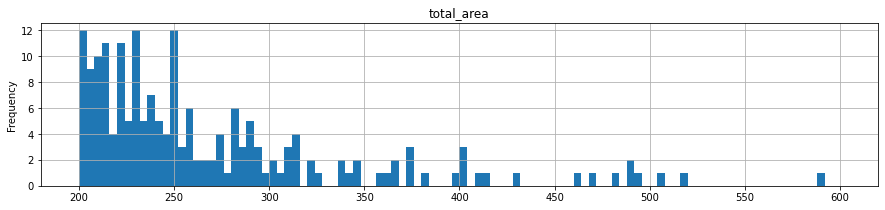

In [61]:
data_clear['total_area'].plot(bins=100, title='total_area', kind='hist', grid=True, figsize=(15,3), range=(200,600));

Ограничим значения показателя общей площади интервалом [25;250)

In [62]:
data_without_tails = data_clear.query('25 <= total_area < 250')

Напишем функцию, определяющую процент потерянных данных, после фильтрации датафрейма от выбросов:

In [63]:
def percent_share(data1, data2):
    res = 100-(len(data1)/len(data2)*100)
    return res  

In [64]:
percent_share(data_without_tails, data_clear)

0.626657025789342

Потеряно чуть более 0.6% данных, при этом "хвосты" на гистограмме стали значительно меньше

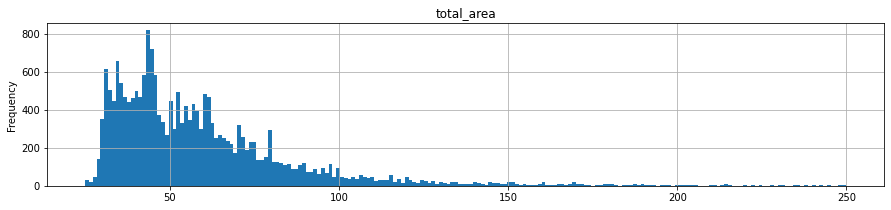

In [65]:
data_without_tails['total_area'].plot(bins=200, title='total_area', kind='hist', grid=True, figsize=(15,3));

In [66]:
data_clear['total_area'].describe()

count    20745.000000
mean        60.541965
std         34.501212
min         14.000000
25%         40.500000
50%         52.200000
75%         70.000000
max        900.000000
Name: total_area, dtype: float64

In [67]:
data_without_tails['total_area'].describe()

count    20615.000000
mean        59.394073
std         28.417164
min         25.000000
25%         40.500000
50%         52.100000
75%         69.605000
max        249.900000
Name: total_area, dtype: float64

Откинутые значения несущественно повышали среднее, очищенные данные приблизились к медиане

*Рассмотрим гистограмму распределения значений жилой площади*

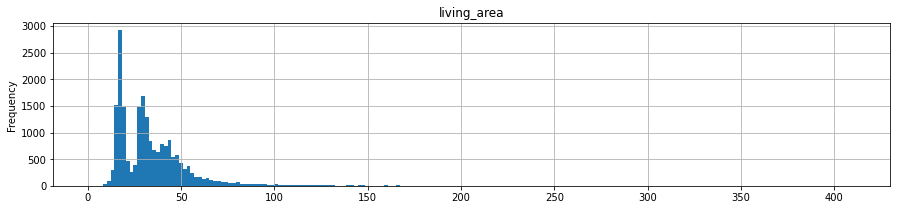

In [68]:
data_clear['living_area'].plot(bins=200, title='living_area', kind='hist', grid=True, figsize=(15,3));

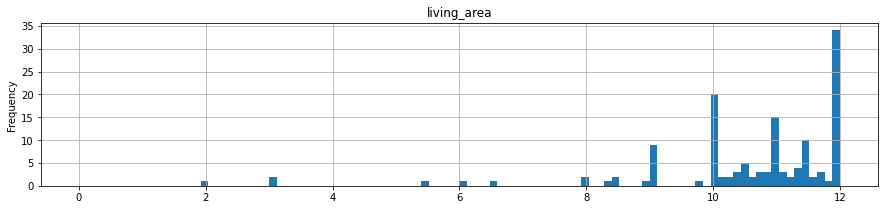

In [69]:
data_clear['living_area'].plot(bins=100, title='living_area', kind='hist', grid=True, figsize=(15,3), range=(0,12));

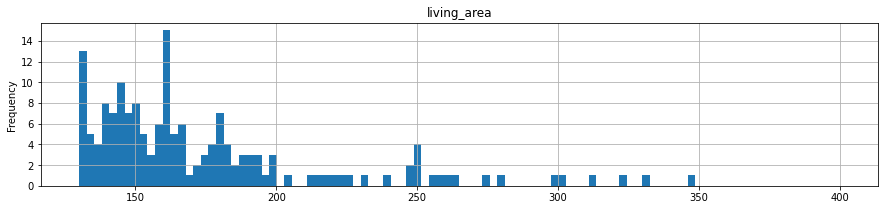

In [70]:
data_clear['living_area'].plot(bins=100, title='living_area', kind='hist', grid=True, figsize=(15,3), range=(130,400));

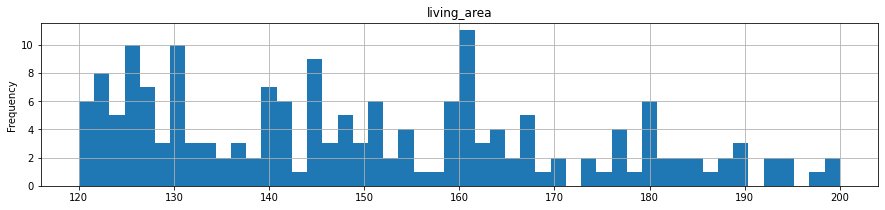

In [71]:
data_clear['living_area'].plot(bins=50, title='living_area', kind='hist', grid=True, figsize=(15,3), range=(120,200));

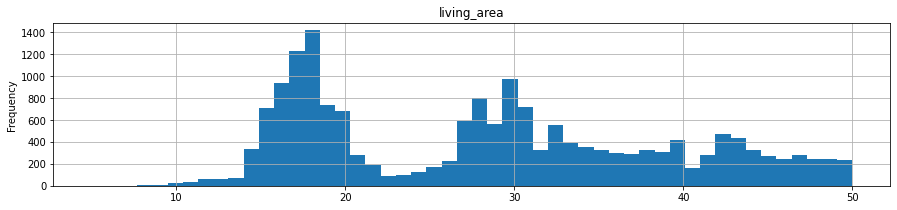

In [72]:
data_clear['living_area'].plot(bins=50, title='living_area', kind='hist', grid=True, figsize=(15,3), range=(5,50));

У показателя жилой площади наблюдается два пика значений: в районе 18 и 30 м2. Скорее всего первый пик данных сформирован под влиянием студий, т.к. почти вся площадь таких помещений считается жилой, второй же пик сформирован под влиянием оставшихся квартир. Также как и у показателей общей площади, у гистограммы жилой площади имеются длинные "хвосты". Ограничим датафрейм объектами с показателем жилой площади в интервале [10;170]

In [73]:
data_without_tails = data_without_tails.query('10 <= living_area <= 170')

In [74]:
percent_share(data_without_tails, data_clear)

0.7568088696071413

Потеряно менее 1% данных (с учетом предыдущей фильтрации), при этом "хвосты" на гистограмме стали значительно меньше

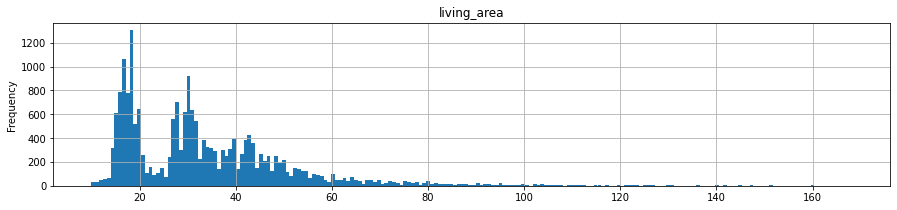

In [75]:
data_without_tails['living_area'].plot(bins=200, title='living_area', kind='hist', grid=True, figsize=(15,3));

In [76]:
data_clear['living_area'].describe()

count    20745.000000
mean        34.644339
std         21.946114
min          2.000000
25%         18.800000
50%         30.100000
75%         42.500000
max        409.700000
Name: living_area, dtype: float64

In [77]:
data_without_tails['living_area'].describe()

count    20588.000000
mean        33.968448
std         18.626446
min         10.000000
25%         18.900000
50%         30.000000
75%         42.300000
max        168.300000
Name: living_area, dtype: float64

Откинутые значения несущественно повышали среднее, очищенные данные приблизились к медиане

*Рассмотрим гистограмму распределения значений площади кухонь*

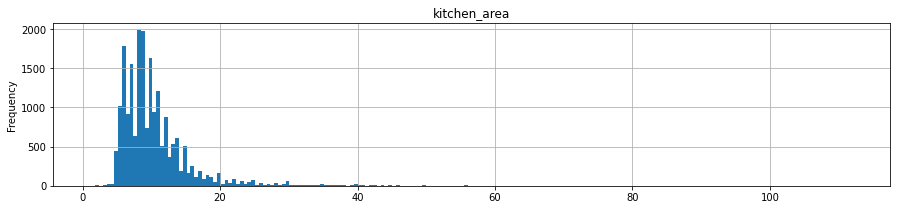

In [78]:
data_clear['kitchen_area'].plot(bins=200, title='kitchen_area', kind='hist', grid=True, figsize=(15,3));

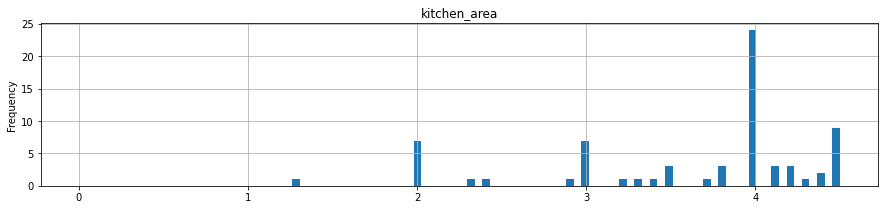

In [79]:
data_clear['kitchen_area'].plot(bins=100, title='kitchen_area', kind='hist', grid=True, figsize=(15,3), range=(0, 4.5));

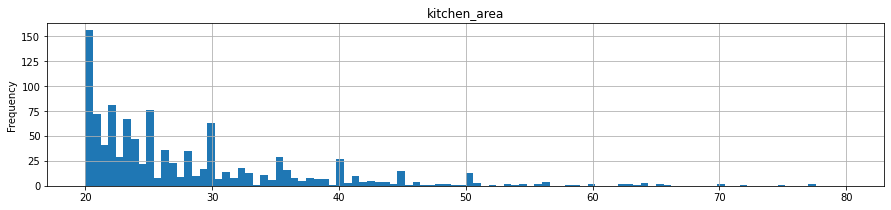

In [80]:
data_clear['kitchen_area'].plot(bins=100, title='kitchen_area', kind='hist', grid=True, figsize=(15,3), range=(20,80));

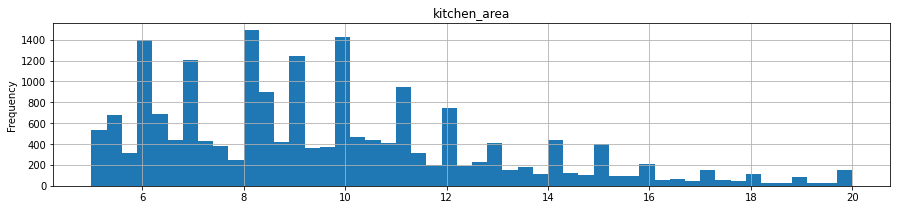

In [81]:
data_clear['kitchen_area'].plot(bins=50, title='kitchen_area', kind='hist', grid=True, figsize=(15,3), range=(5,20));

На гистограмме видно пики в районе 6,8 и 10 м2 и длинные хвосты вплоть до 120 м2. Удалим из датафрейма значения площади кухни менее 4 м2 и больше 50 м2 и проанализируем сколько значений датафрейма мы потеряем.

In [82]:
data_without_tails = data_without_tails.query('4 <kitchen_area < 50')

In [83]:
percent_share(data_without_tails, data_clear)

1.1472644010604967

Потеряно чуть более 1% данных (с учетом предыдущей фильтрации), при этом "хвосты" на гистограмме стали значительно меньше

In [84]:
data_clear['kitchen_area'].describe()

count    20745.000000
mean        10.521592
std          5.851194
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

In [85]:
data_without_tails['kitchen_area'].describe()

count    20507.000000
mean        10.331004
std          4.972718
min          4.100000
25%          7.000000
50%          9.000000
75%         11.950000
max         49.400000
Name: kitchen_area, dtype: float64

Откинутые значения несущественно повышали среднее, очищенные данные приблизились к медиане

*Рассмотрим гистограмму распределения стоимости анализируемых объектов*

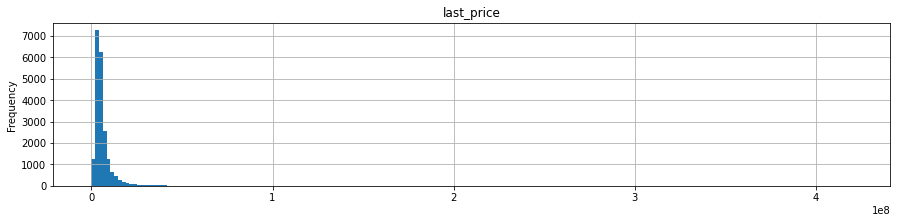

In [86]:
data_clear['last_price'].plot(bins=200, title='last_price', kind='hist', grid=True, figsize=(15,3));

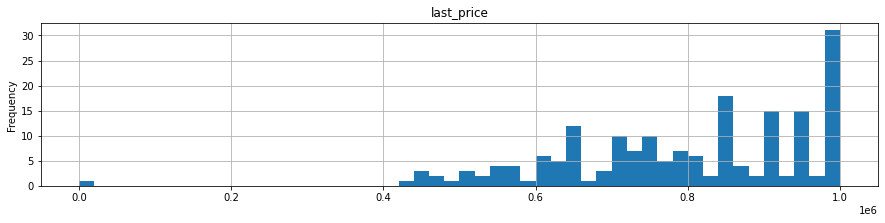

In [87]:
data_clear['last_price'].plot(bins=50, title='last_price', kind='hist', grid=True, figsize=(15,3), range=(0,1000000));

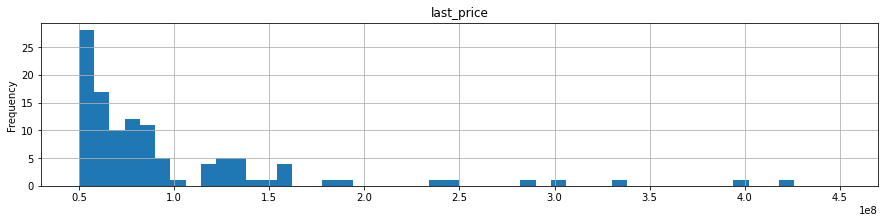

In [88]:
(data_clear['last_price'].plot(bins=50, title='last_price', kind='hist', 
                               grid=True, figsize=(15,3), range=(50000000,450000000)));

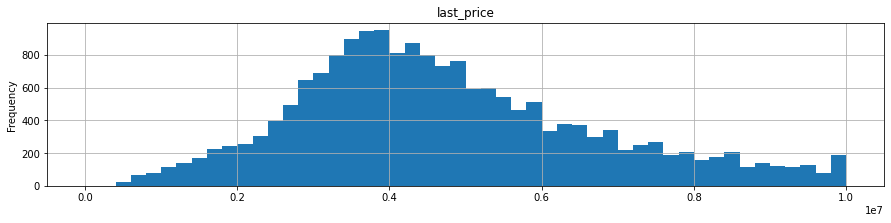

In [89]:
(data_clear['last_price'].plot(bins=50, title='last_price', kind='hist', 
                               grid=True, figsize=(15,3), range=(0,10000000)));

На гистограмме видно пик в районе 4 млн руб и длинные хвосты вплоть до 420 млн руб. Удалим из датафрейма значения стоимости объектов менее 600 тыс руб и более 100 млн руб и проанализируем сколько значений датафрейма мы потеряем.

In [90]:
data_without_tails = data_without_tails.query('600000 <= last_price <= 100000000')

In [91]:
percent_share(data_without_tails, data_clear)

1.29669799951796

Потеряно почти 1.3 % данных (с учетом предыдущей фильтрации), при этом "хвосты" на гистограмме стали значительно меньше

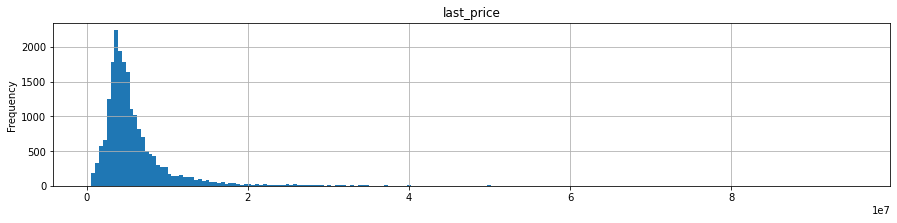

In [92]:
data_without_tails['last_price'].plot(bins=200, title='last_price', kind='hist', grid=True, figsize=(15,3));

In [93]:
data_clear['last_price'].describe()

count    2.074500e+04
mean     6.512535e+06
std      9.615362e+06
min      1.219000e+04
25%      3.500000e+06
50%      4.700000e+06
75%      6.800000e+06
max      4.200000e+08
Name: last_price, dtype: float64

In [94]:
data_without_tails['last_price'].describe()

count    2.047600e+04
mean     6.087316e+06
std      5.469258e+06
min      6.000000e+05
25%      3.500000e+06
50%      4.700000e+06
75%      6.750000e+06
max      9.500000e+07
Name: last_price, dtype: float64

Откинутые значения существенно понизили среднеквадратичное отклонение, т.к. в столбце были "хвосты" с очень большими значениями. Понизилось среднее, очищенные данные приблизились к медиане

*Рассмотрим гистограмму распределения количества комнат в анализируемых объектах*

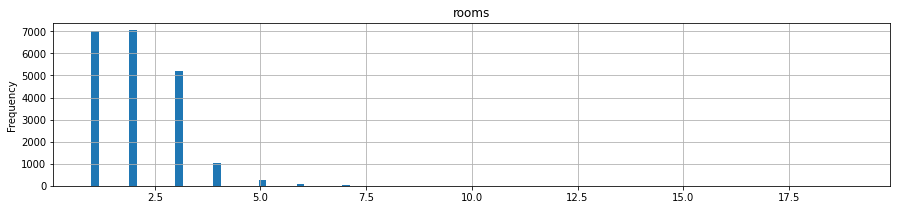

In [95]:
data_clear['rooms'].plot(bins=100, title='rooms', kind='hist', grid=True, figsize=(15,3));

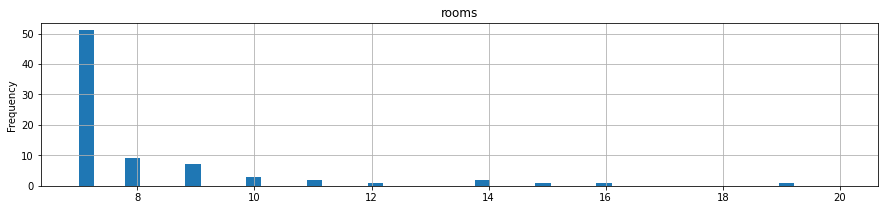

In [96]:
data_clear['rooms'].plot(bins=50, title='rooms', kind='hist', grid=True, figsize=(15,3), range=(7,20));

На гистограмме видно что большинство значений количества комнат находится в интервале от 0 до 5. Удалим из датафрейма значения количества комнат более 7 и проанализируем сколько значений датафрейма мы потеряем.

In [97]:
data_without_tails = data_without_tails.query('rooms <= 7')

In [98]:
percent_share(data_without_tails, data_clear)

1.3449023861171412

Потеряно чуть более 1% данных (с учетом предыдущих фильтраций), при этом "хвосты" на гистограмме стали значительно меньше

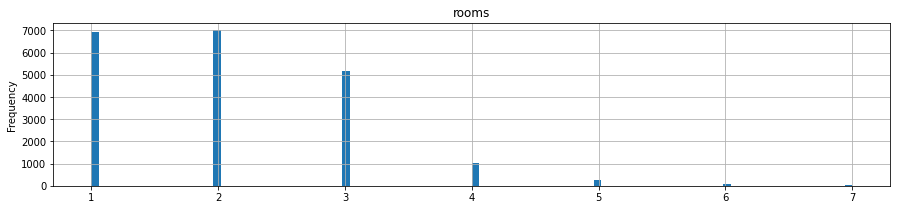

In [99]:
data_without_tails['rooms'].plot(bins=100, title='rooms', kind='hist', grid=True, figsize=(15,3));

In [100]:
data_clear['rooms'].describe()

count    20745.000000
mean         2.095927
std          1.065650
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

In [101]:
data_without_tails['rooms'].describe()

count    20466.000000
mean         2.073585
std          0.995106
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

Откинутые значения несущественно повышали среднее, очищенные данные приблизились к медиане

*Рассмотрим гистограмму распределения значений высоты потолка в анализируемых объектах*

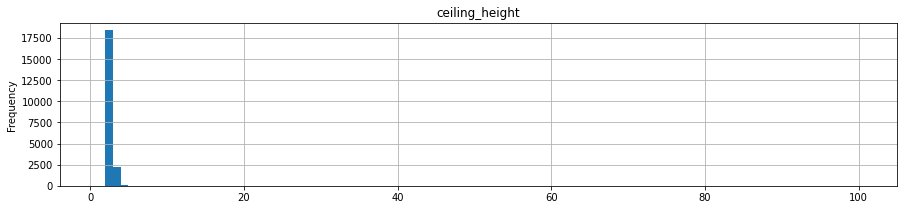

In [102]:
data_clear['ceiling_height'].plot(bins=100, title='ceiling_height', kind='hist', grid=True, figsize=(15,3));

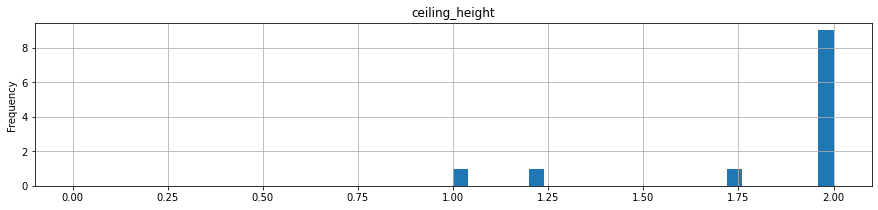

In [103]:
data_clear['ceiling_height'].plot(bins=50, title='ceiling_height', kind='hist', grid=True, figsize=(15,3), range=(0, 2));

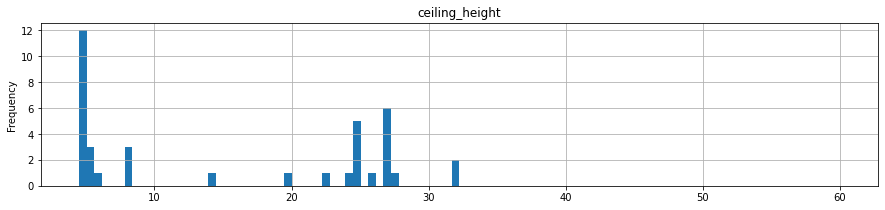

In [104]:
data_clear['ceiling_height'].plot(bins=100, title='ceiling_height', kind='hist', grid=True, figsize=(15,3), range=(4.5, 60));

На гистограмме видно, что большинство значений высот потолков находится в интервале от 2 до 4. Проанализируем список уникальных значений по данному столбцу, с целью выявления ошибочно введенных значений

In [105]:
data_without_tails.sort_values(by='ceiling_height')['ceiling_height'].unique()

array([  1.  ,   1.2 ,   1.75,   2.  ,   2.25,   2.3 ,   2.4 ,   2.45,
         2.46,   2.47,   2.48,   2.49,   2.5 ,   2.51,   2.52,   2.53,
         2.54,   2.55,   2.56,   2.57,   2.58,   2.59,   2.6 ,   2.61,
         2.62,   2.63,   2.64,   2.65,   2.66,   2.67,   2.68,   2.69,
         2.7 ,   2.71,   2.72,   2.73,   2.74,   2.75,   2.76,   2.77,
         2.78,   2.79,   2.8 ,   2.81,   2.82,   2.83,   2.84,   2.85,
         2.86,   2.87,   2.88,   2.89,   2.9 ,   2.91,   2.92,   2.93,
         2.94,   2.95,   2.96,   2.97,   2.98,   3.  ,   3.01,   3.02,
         3.03,   3.04,   3.05,   3.06,   3.07,   3.08,   3.09,   3.1 ,
         3.11,   3.12,   3.13,   3.14,   3.15,   3.16,   3.17,   3.18,
         3.2 ,   3.21,   3.22,   3.23,   3.24,   3.25,   3.26,   3.27,
         3.28,   3.29,   3.3 ,   3.31,   3.32,   3.33,   3.34,   3.35,
         3.36,   3.37,   3.38,   3.39,   3.4 ,   3.42,   3.44,   3.45,
         3.46,   3.47,   3.48,   3.49,   3.5 ,   3.51,   3.52,   3.53,
      

In [106]:
data_without_tails['ceiling_height'] = (
    data_without_tails['ceiling_height']
        .replace(20.00, 2.00)
        .replace(22.60, 2.26)
        .replace(24.00, 2.40)
        .replace(25.00, 2.50)
        .replace(26.00, 2.60)
        .replace(27.00, 2.70)
        .replace(27.50, 2.75)
        .replace(32.00, 3.20)
)

Проверим что данные отфильтровались верно:

In [107]:
data_without_tails.sort_values(by='ceiling_height')['ceiling_height'].unique()

array([  1.  ,   1.2 ,   1.75,   2.  ,   2.25,   2.26,   2.3 ,   2.4 ,
         2.45,   2.46,   2.47,   2.48,   2.49,   2.5 ,   2.51,   2.52,
         2.53,   2.54,   2.55,   2.56,   2.57,   2.58,   2.59,   2.6 ,
         2.61,   2.62,   2.63,   2.64,   2.65,   2.66,   2.67,   2.68,
         2.69,   2.7 ,   2.71,   2.72,   2.73,   2.74,   2.75,   2.76,
         2.77,   2.78,   2.79,   2.8 ,   2.81,   2.82,   2.83,   2.84,
         2.85,   2.86,   2.87,   2.88,   2.89,   2.9 ,   2.91,   2.92,
         2.93,   2.94,   2.95,   2.96,   2.97,   2.98,   3.  ,   3.01,
         3.02,   3.03,   3.04,   3.05,   3.06,   3.07,   3.08,   3.09,
         3.1 ,   3.11,   3.12,   3.13,   3.14,   3.15,   3.16,   3.17,
         3.18,   3.2 ,   3.21,   3.22,   3.23,   3.24,   3.25,   3.26,
         3.27,   3.28,   3.29,   3.3 ,   3.31,   3.32,   3.33,   3.34,
         3.35,   3.36,   3.37,   3.38,   3.39,   3.4 ,   3.42,   3.44,
         3.45,   3.46,   3.47,   3.48,   3.49,   3.5 ,   3.51,   3.52,
      

Проанализировав уникальные значения столбца ceiling_height мы видим значения высоты потолков в 1.0 и 1.2 и 1.75  метра, что является крайне нетипичным значением и возможно вызвано ошибкой, поэтому ограничим высоту потолка значениями не менее 2.0 м . Также можно предположить, что значения 20, 22.6, 24, 25, 26, 27, 27.5, и 32 имеют ошибку в порядке числа, заменим их соответственно на значения 2.0, 2.26, 2.4 и так далее. Также удалим все значения высоты потолка более менее 2.0 и более 4.5 метров, т.к. данные значения являются редкими, однако могут повлиять на результаты анализа. 

In [108]:
data_without_tails = data_without_tails.query('2 < ceiling_height < 4.5')

In [109]:
percent_share(data_without_tails, data_clear)

1.4798746685948316

Потеряно менее 1.5% данных (с учетом предыдущих фильтраций), при этом "хвосты" на гистограмме стали значительно меньше

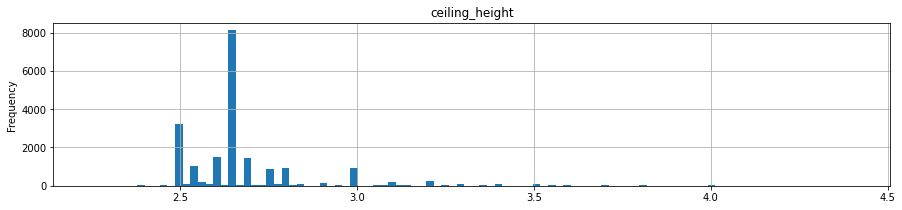

In [110]:
data_without_tails['ceiling_height'].plot(bins=100, title='ceiling_height', kind='hist', grid=True, figsize=(15,3));

Большинство значений высот потолка соответствует высотам 2,5 и 2,65 метра, что соответсвует показателям высот массовой застройки "советского" периода, как правило преобладающим среди объявлений о продаже недвижимости

In [111]:
data_clear['ceiling_height'].describe()

count    20745.000000
mean         2.723611
std          1.000351
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

In [112]:
data_without_tails['ceiling_height'].describe()

count    20438.000000
mean         2.693361
std          0.208731
min          2.250000
25%          2.600000
50%          2.650000
75%          2.700000
max          4.400000
Name: ceiling_height, dtype: float64

Откинутые значения несущественно повышали среднее, очищенные данные практически совпадают с медианой

*Рассмотрим гистограмму распределения типа этажей ("первый", "другой", "последний") в анализируемых объектах*

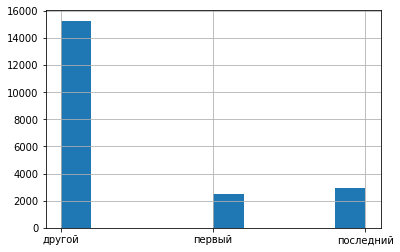

In [113]:
data_clear['floor_type'].hist();

Данная гистограмма в фильтрации не нуждается. На графике видно что большинствыо этажей имеют значение "другой", что логично, т.к. таких объявлений большинство. Количество первых и последних этажей приблизительно равное, первых этажей чуть меньше, т.к. иногда первые этажи в жилых домах заняты нежилыми помещениями

*Рассмотрим гистограмму распределения значений общего количества этажей в анализируемых объектах*

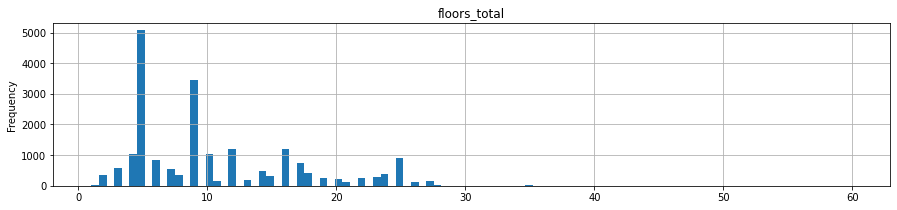

In [114]:
data_clear['floors_total'].plot(bins=100, title='floors_total', kind='hist', grid=True, figsize=(15,3));

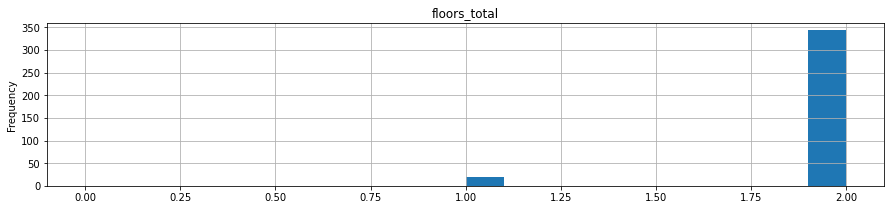

In [115]:
data_clear['floors_total'].plot(bins=20, title='floors_total', kind='hist', grid=True, figsize=(15,3), range=(0,2));

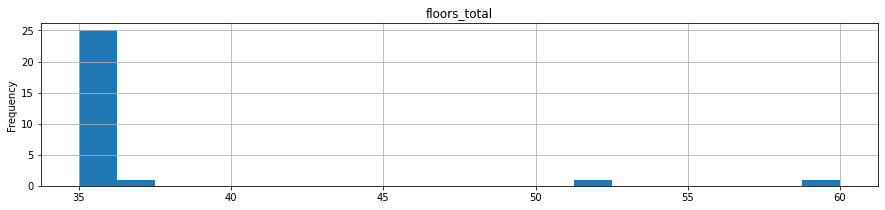

In [116]:
data_clear['floors_total'].plot(bins=20, title='floors_total', kind='hist', grid=True, figsize=(15,3), range=(35,60));

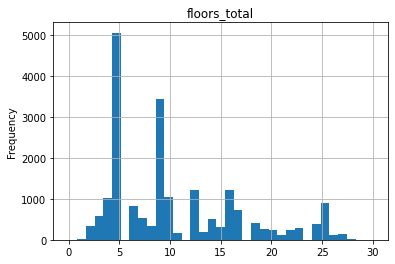

In [117]:
data_clear['floors_total'].plot(bins=35, title='floors_total', kind='hist', grid=True, range=(0,30));   

На гистограмме видно, что большинство значений общего количества этажей находится в интервале от 1 до 35. Удалим из датафрейма значения общего количества этажей более 35 и проанализируем сколько значений датафрейма мы потеряем.

In [118]:
data_without_tails = data_without_tails.query('floors_total <= 35')

In [119]:
percent_share(data_without_tails, data_clear)

1.5039768618944294

Потеряно 1,5% данных (с учетом предыдущих фильтраций), при этом "хвосты" на гистограмме стали значительно меньше

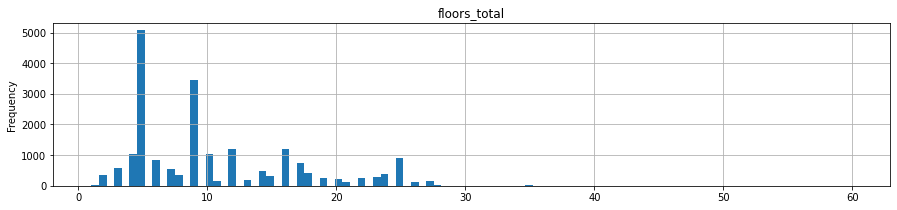

In [120]:
data_clear['floors_total'].plot(bins=100, title='floors_total', kind='hist', grid=True, figsize=(15,3));

Большинство значений общего количества этажей объектов соответствует 5 и 9 этажей, что соответсвует показателям этажности массовой застройки "советского" периода, как правило преобладающим среди объявлений о продаже недвижимости

In [121]:
data_clear['floors_total'].describe()

count    20745.000000
mean        10.586021
std          6.523042
min          1.000000
25%          5.000000
50%          9.000000
75%         15.000000
max         60.000000
Name: floors_total, dtype: float64

In [122]:
data_without_tails['floors_total'].describe()

count    20433.000000
mean        10.611021
std          6.498646
min          1.000000
25%          5.000000
50%          9.000000
75%         15.000000
max         35.000000
Name: floors_total, dtype: float64

Фильтрация несущественно повысила среднее (за счет снижения количества записей), при этом среднеквадратичное отклонение уменьшилось.

*Рассмотрим гистограмму распределения значений расстояния до центра города в анализируемых объектах*

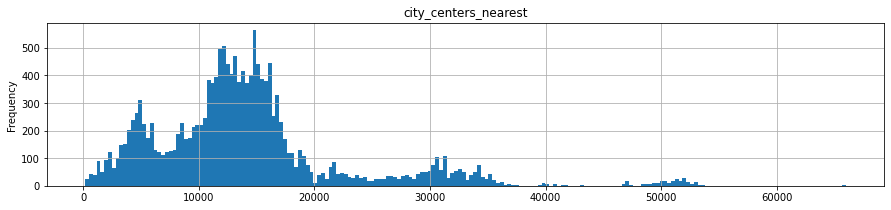

In [123]:
data_clear['city_centers_nearest'].plot(bins=200, title='city_centers_nearest', kind='hist', grid=True, figsize=(15,3));

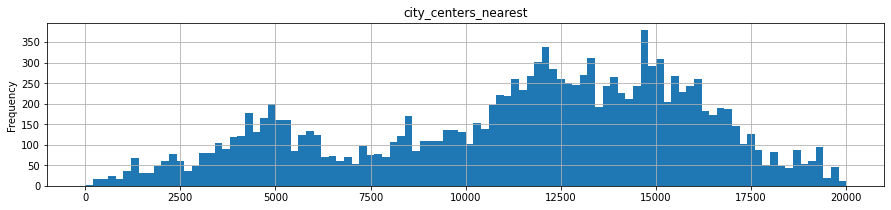

In [124]:
(data_clear['city_centers_nearest'].plot(bins=100, title='city_centers_nearest', 
                                         kind='hist', grid=True, figsize=(15,3), range=(0,20000)));

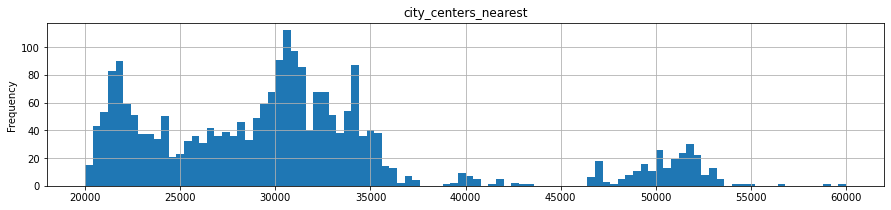

In [125]:
(data_clear['city_centers_nearest'].plot(bins=100, title='city_centers_nearest', 
                                         kind='hist', grid=True, figsize=(15,3), range=(20000,60000)));

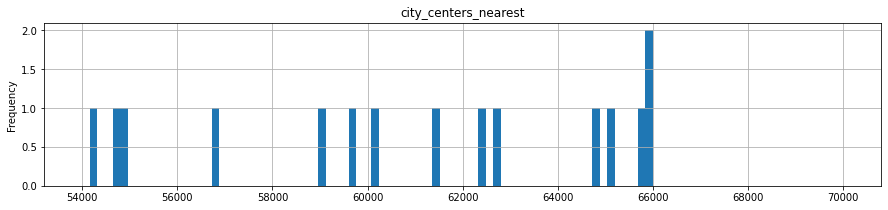

In [126]:
(data_clear['city_centers_nearest'].plot(bins=100, title='city_centers_nearest', 
                                         kind='hist', grid=True, figsize=(15,3), range=(54000,70000)));

На гистограмме видно, что  значения расстояний до центра города имеют пик в районе 5000 метров (скорее всего это объекты недвижимости, расположенные в центре города), от 10000 до 17500 (объекты спальных районов города), а также есть отдельные всплески в районе 30 000 и 50 000 м. Последние, скоре всего являются объявлениями из городов расположенных на расстоянии 30 км (Колпино, Пушкин) и 50 км (Тосно). Оставим их в датафрейме, т.к. исключив их, мы удалим все объявления из данных городов. Исключим из датафрейма все значения больше 54 000 м

In [127]:
data_clear_temp1 = data_clear[~data_clear['city_centers_nearest'].isna()]

In [128]:
data_without_tails_temp1 = data_without_tails[(data_without_tails['city_centers_nearest'] <= 54000) & \
                                               (~data_without_tails['city_centers_nearest'].isna())]

In [129]:
percent_share(data_without_tails_temp1, data_clear_temp1)

1.6718075262183874

Потеряно почти 1.7 % данных (с учетом предыдущих фильтраций). Для того чтобы строки с пропусками в столбце 'city_centers_nearest' не влияли на расчет выше, они были отфильтрованы и полученные датасеты записаны во временные переменные, чтобы срез не записался в основные рабочие переменные data_clear и data_without_tails. 

In [130]:
data_clear_temp1['city_centers_nearest'].describe()

count    16210.000000
mean     14251.301666
std       8670.481780
min        181.000000
25%       9360.250000
50%      13114.000000
75%      16263.750000
max      65968.000000
Name: city_centers_nearest, dtype: float64

In [131]:
data_without_tails_temp1['city_centers_nearest'].describe()

count    15939.000000
mean     14278.243679
std       8543.357929
min        181.000000
25%       9487.000000
50%      13149.000000
75%      16271.000000
max      53568.000000
Name: city_centers_nearest, dtype: float64

По выведенным статистическим показателям видно, что несмотря на фильтрацию данных, среднее значение незначительно увеличилось (из за уменьшения количества записей.Среднеквадратичное отклонение уменьшилось, увеличилось значение квартилей

*Рассмотрим гистограмму распределения значений расстояния до ближайшего парка в анализируемых объектах*

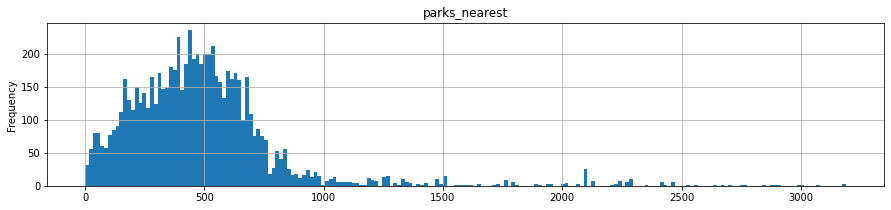

In [132]:
data_clear['parks_nearest'].plot(bins=200, title='parks_nearest', kind='hist', grid=True, figsize=(15,3));

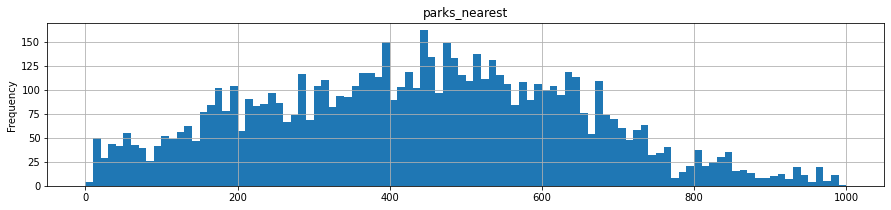

In [133]:
data_clear['parks_nearest'].plot(bins=100, title='parks_nearest', kind='hist', grid=True, figsize=(15,3), range=(0,1000));

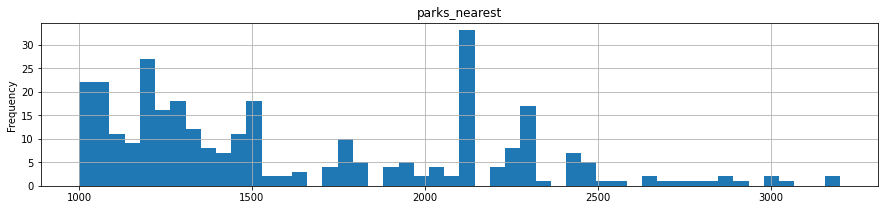

In [134]:
data_clear['parks_nearest'].plot(bins=50, title='parks_nearest', kind='hist', grid=True, figsize=(15,3), range=(1000,3200));

На гистограмме видно что большинство значений расстояния до ближайшего парка, находится в интервале от 0 до 800. Удалим из датафрейма значения расстояния до ближайшего парка более 2500 метров и проанализируем сколько значений датафрейма мы потеряем.

In [135]:
data_clear_temp2 = data_clear[~data_clear['parks_nearest'].isna()]

In [136]:
data_without_tails_temp2 = data_without_tails[(data_without_tails['parks_nearest'] < 2500) & \
                                               (~data_without_tails['parks_nearest'].isna())]

In [137]:
percent_share(data_without_tails_temp2, data_clear_temp2)

2.2856351295193207

Потеряно почти 2.3 % данных (с учетом предыдущих фильтраций), Для того чтобы строки с пропусками в столбце 'parks_nearest' не влияли на расчет выше, они были отфильтрованы и полученные датасеты записаны во временные переменные, чтобы срез не записался в основные рабочие переменные data_clear и data_without_tails.

In [138]:
data_clear_temp2['parks_nearest'].describe()

count    7219.000000
mean      487.708685
std       337.007878
min         1.000000
25%       287.500000
50%       453.000000
75%       610.000000
max      3190.000000
Name: parks_nearest, dtype: float64

In [139]:
data_without_tails_temp2['parks_nearest'].describe()

count    7054.000000
mean      483.279983
std       318.290509
min         1.000000
25%       288.000000
50%       453.500000
75%       610.000000
max      2467.000000
Name: parks_nearest, dtype: float64

По выведенным статистическим показателям видно, что среднее значение и среднеквадратичное отклонение уменьшилось, увеличилось значение квартилей, незначительно увеличился первый квартиль. Это происходит из за того, что в данном столбце содержатся пропуски, которые удаляются при выполнении среза. Эти данные могут нам пригодиться при выполнении дальнейшего анализа, т.к. мы не понимаем данные с какими параметрами мы удалили, поэтому на данном этапе исследования восстановим их (для этого переименовали переменную, чтобы срез не записался в data_without_tails).

In [140]:
# check
data_without_tails.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20433 entries, 0 to 20744
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   total_images                    20433 non-null  int64         
 1   last_price                      20433 non-null  float64       
 2   total_area                      20433 non-null  float64       
 3   first_day_exposition            20433 non-null  datetime64[ns]
 4   rooms                           20433 non-null  int64         
 5   ceiling_height                  20433 non-null  float64       
 6   floors_total                    20433 non-null  int64         
 7   living_area                     20433 non-null  float64       
 8   floor                           20433 non-null  int64         
 9   is_apartment                    2469 non-null   object        
 10  studio                          20433 non-null  bool          
 11  op

In [141]:
# check

# Показатели о кол-ве объявлений в датасете, минимальных и максимальных значениях 
# в выбранных параметрах о продаже квартир

(
    data_without_tails[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 
                        'last_price', 'living_area',  'kitchen_area',
                         'floor', 'floors_total']]
    .apply (['count', 'min', 'max'])   
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
count,"20,433.00","20,433.00","20,433.00","17,624.00","20,433.00","20,433.00","20,433.00","20,433.00","20,433.00"
min,1.00,25.00,2.25,1.00,"600,000.00",10.00,4.10,1.00,1.00
max,7.00,248.00,4.40,"1,580.00","95,000,000.00",167.00,49.40,33.00,35.00


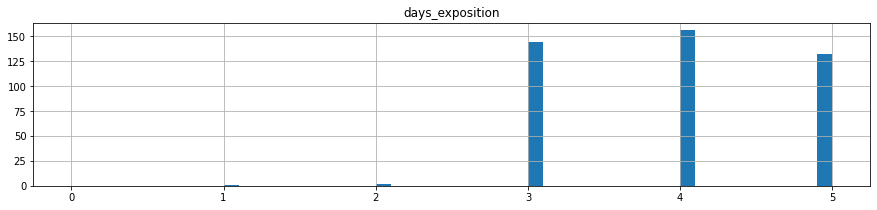

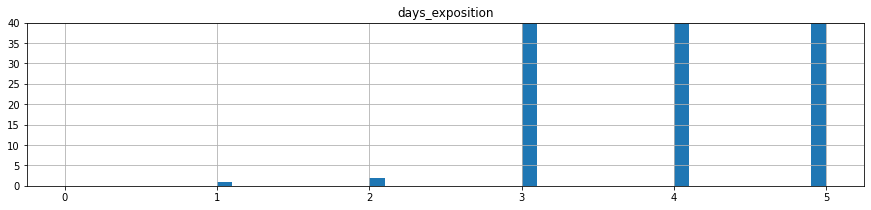

In [142]:
# check
data_without_tails.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5));

data_without_tails.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5))
plt.ylim(0, 40);

In [143]:
    (
        data[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  'kitchen_area',
              'floor', 'floors_total']]
        .apply (['count', 'min', 'max', 'median'])   
        .style.format("{:,.2f}")
    )

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
count,"23,699.00","23,699.00","14,504.00","20,518.00","23,699.00","21,796.00","21,421.00","23,699.00","23,613.00"
min,0.00,12.00,1.00,1.00,"12,190.00",2.00,1.30,1.00,1.00
max,19.00,900.00,100.00,"1,580.00","763,000,000.00",409.70,112.00,33.00,60.00
median,2.00,52.00,2.65,95.00,"4,650,000.00",30.00,9.10,4.00,9.00


In [144]:
    (
        data_without_tails[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  'kitchen_area',
              'floor', 'floors_total']]
        .apply (['count', 'min', 'max', 'median'])   
        .style.format("{:,.2f}")
    )

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
count,"20,433.00","20,433.00","20,433.00","17,624.00","20,433.00","20,433.00","20,433.00","20,433.00","20,433.00"
min,1.00,25.00,2.25,1.00,"600,000.00",10.00,4.10,1.00,1.00
max,7.00,248.00,4.40,"1,580.00","95,000,000.00",167.00,49.40,33.00,35.00
median,2.00,52.10,2.65,101.00,"4,700,000.00",30.00,9.00,4.00,9.00


In [145]:
# check

try:
    df_check = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')
# если не получилось прочитать файл из локальной папки, то загружаем данные из сети
except:
    df_check = pd.read_csv('real_estate_data.csv', sep='\t')

In [146]:
# check
df_check.rooms.value_counts().to_frame()

,rooms
1,8047
2,7940
3,5814
4,1180
5,326
0,197
6,105
7,59
8,12
9,8


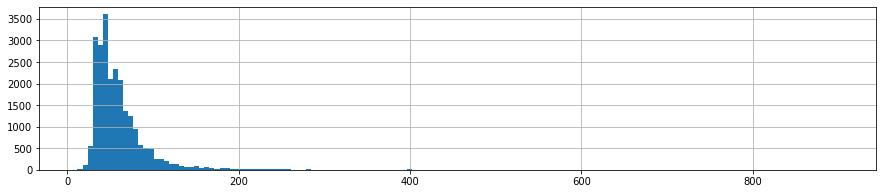

In [147]:
# check
df_check.total_area.hist(bins = 150, figsize = (15,3));

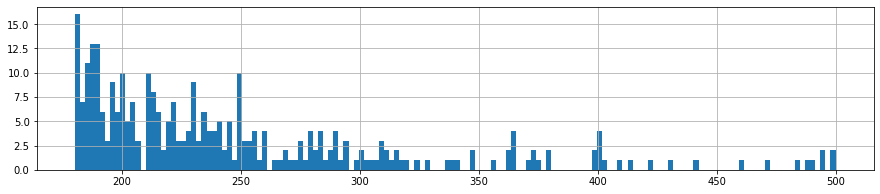

In [148]:
# check
df_check.total_area.hist(bins = 150, figsize = (15,3), range = (180,500));

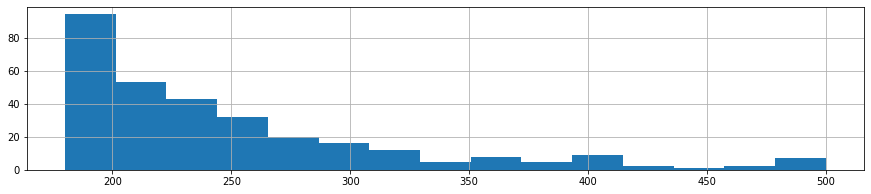

In [149]:
# check
df_check.total_area.hist(bins = 15, figsize = (15,3), range = (180,500));

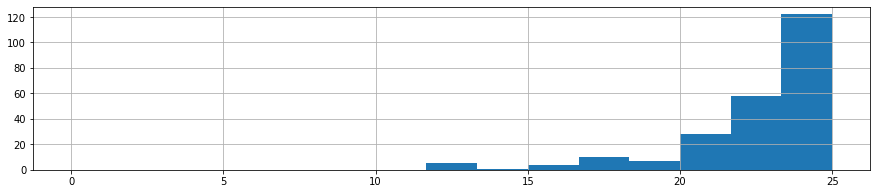

In [150]:
# check
df_check.total_area.hist(bins = 15, figsize = (15,3), range = (0,25));

In [151]:
# check

# Значения параметров объектов недвижимости на разных квантилях

(
    data_clear[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  
        'kitchen_area', 'floor',   'floors_total']]
    .quantile([0.0012, 0.01, .5, .99, .9988]) # выбираем размах в 0,9976 квантилей 
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
0.0012,1.00,23.26,2.40,3.00,"600,000.00",10.00,3.79,1.00,2.00
0.01,1.00,29.00,2.50,4.00,"1,070,000.00",13.10,5.00,1.00,2.00
0.5,2.00,52.20,2.65,102.00,"4,700,000.00",30.10,9.00,4.00,9.00
0.99,5.00,191.11,3.60,"1,075.00","35,000,000.00",119.41,35.00,22.56,26.00
0.9988,8.00,363.11,5.32,"1,371.73","120,214,400.00",218.21,60.00,26.00,35.00


In [152]:
# check

# Значения параметров объектов недвижимости на разных квантилях

(
    data_without_tails[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  
        'kitchen_area', 'floor',   'floors_total']]
    .quantile([0.0012, 0.01, .5, .99, .9988]) # выбираем размах в 0,9976 квантилей 
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
0.0012,1.00,27.00,2.40,3.00,"685,184.00",10.45,4.70,1.00,2.00
0.01,1.00,29.40,2.50,4.00,"1,100,000.00",13.59,5.00,1.00,2.00
0.5,2.00,52.10,2.65,101.00,"4,700,000.00",30.00,9.00,4.00,9.00
0.99,5.00,168.14,3.54,"1,073.54","28,000,000.00",102.00,31.00,22.00,26.00
0.9988,7.00,223.11,4.00,"1,373.97","61,563,878.27",151.24,43.59,26.00,28.00


#### Анализ скорости продажи квартир (day_exposition)

*Изучим как быстро продавались квартиры (столбец days_exposition). Этот параметр показывает, сколько дней было размещено каждое объявление*

*Построим гистограмму распределения значений времени экспозиции объявлений датафрейма, определим среднее и медианное значение*

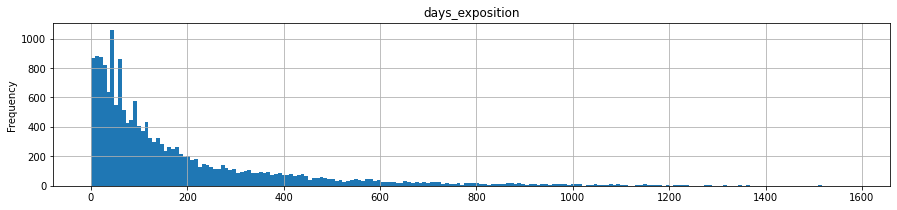

In [153]:
data_without_tails['days_exposition'].plot(bins=200, title='days_exposition', kind='hist', grid=True, figsize=(15,3));

In [154]:
(data_without_tails['days_exposition']
    .describe()
    .round(2)
)

count    17624.00
mean       184.76
std        221.43
min          1.00
25%         44.00
50%        101.00
75%        238.00
max       1580.00
Name: days_exposition, dtype: float64

Мы видим, что среднее значение в 1.8 раза отличается от медианы, что говорит нам о наличии выбросов в виде очень больших сроков экспозиции объявлений. Такие выбросы могут быть образованы как по причине плохого состояния/расположения объекта или сильно завышенной цены, так и по причине того, что владельцы забывают снять объявление с площадки после успешной сделки.

Также на гистограмме выше можно увидеть, что бОльшая часть объектов продается в первые 200 дней после размещения объявления. Уменьшим диапазон построения гистограммы, чтобы рассмотреть этот диапазон подробнее.

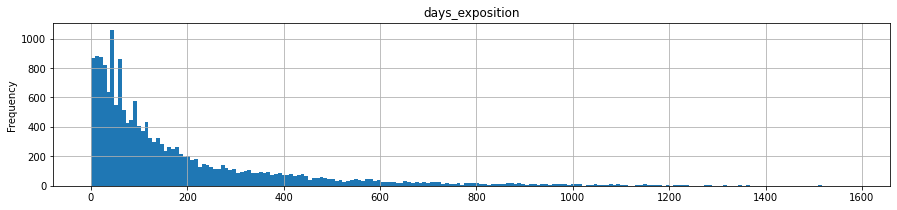

In [155]:
data_without_tails['days_exposition'].plot(bins=200, title='days_exposition', kind='hist', grid=True, figsize=(15,3));

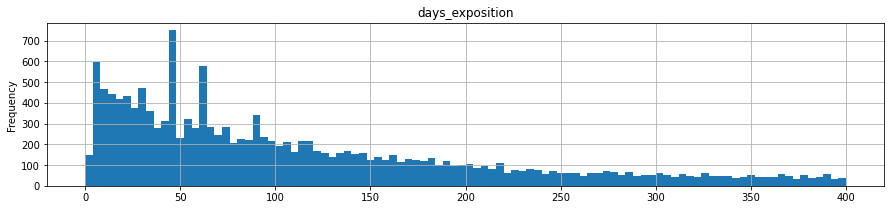

In [156]:
(data_without_tails['days_exposition'].plot(bins=100, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(0,400)));

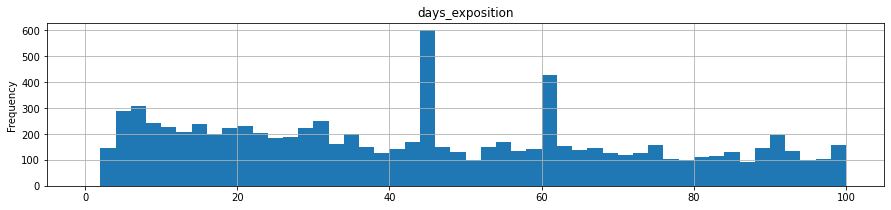

In [157]:
(data_without_tails['days_exposition'].plot(bins=50, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(0,100)));

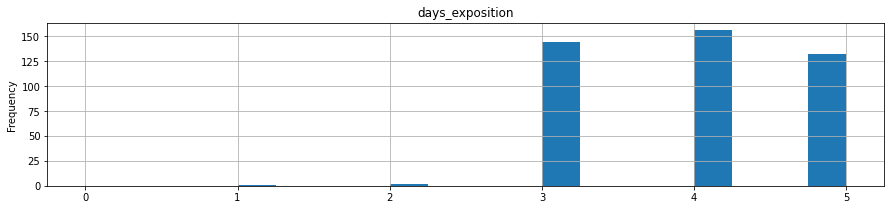

In [158]:
(data_without_tails['days_exposition'].plot(bins=20, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(0,5)));

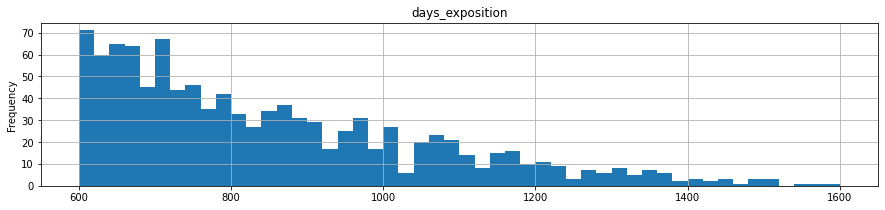

In [159]:
(data_without_tails['days_exposition'].plot(bins=50, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(600,1600)));

На отфильтрованной гистограмме мы видим отдельные сильные всплески в районе 45 и 60 дней. Т.к. данные значения соответствуют ровно 1,5; 2  месяцам, скорее всего данные всплески не связаны с продажами, а вызваны некими особенностями площадки объявлений (например в указанные сроки нужно доплатить за дальнейшее размещение объявления, люди отказываются платить и срок экспозиции заканчивается). Попробуем временно отфильтровать данные всплески и выполнить повторный анализ

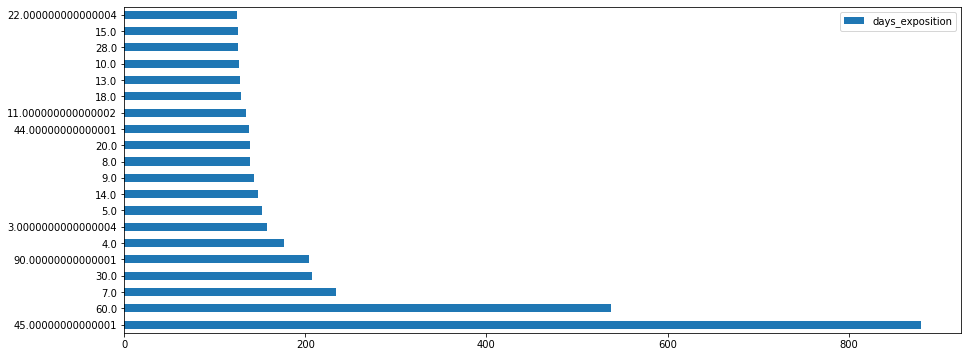

In [160]:
# check
# Моды на сырых данных
     
df_check['days_exposition'].value_counts().to_frame().head(20).plot(kind = 'barh', figsize = (15,6), rot = 0);

In [161]:
data_without_tails_temp3 = data_without_tails.query('not 45 <= days_exposition <= 46 and  days_exposition != 60')

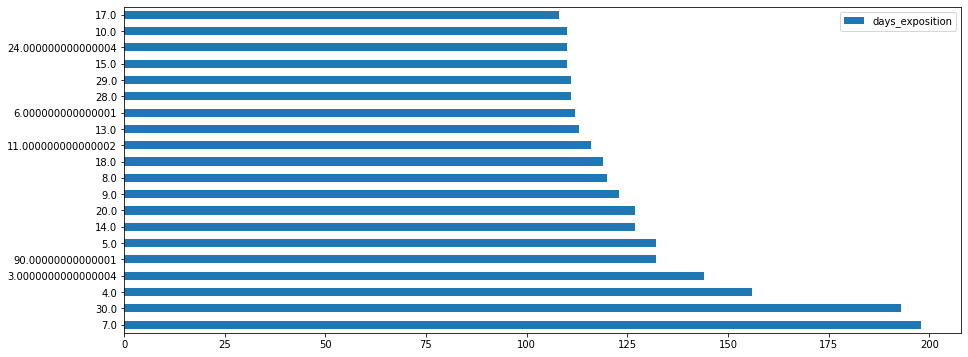

In [162]:
data_without_tails_temp3['days_exposition'].value_counts().to_frame().head(20).plot(kind = 'barh', figsize = (15,6), rot = 0);

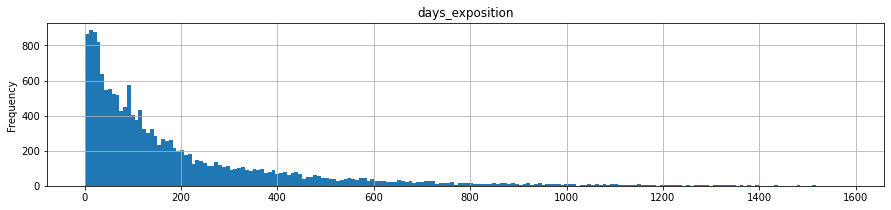

In [163]:
data_without_tails_temp3['days_exposition'].plot(bins=200, title='days_exposition', kind='hist', grid=True, figsize=(15,3));

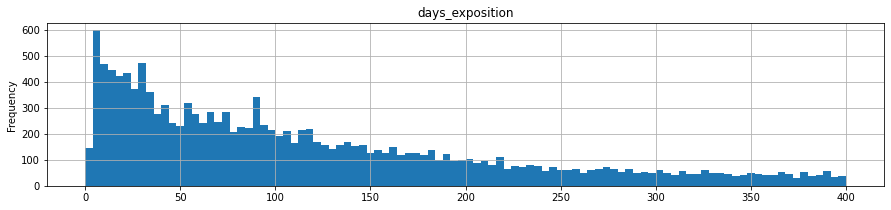

In [164]:
(data_without_tails_temp3['days_exposition'].plot(bins=100, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(0,400)));

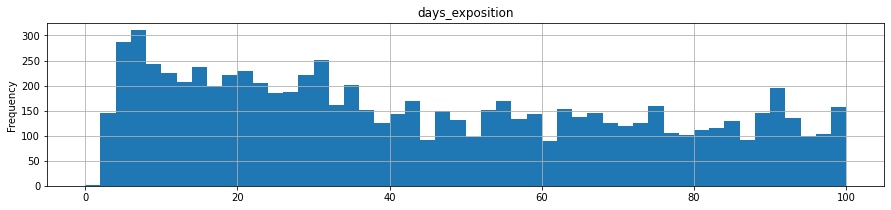

In [165]:
(data_without_tails_temp3['days_exposition'].plot(bins=50, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(0,100)));

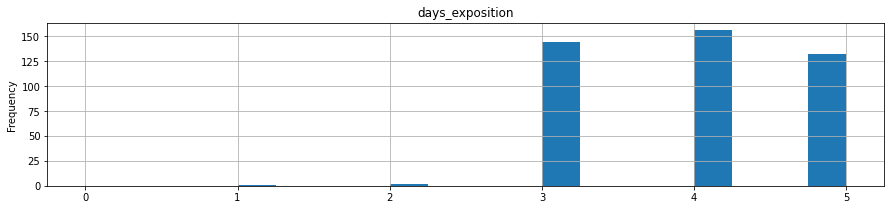

In [166]:
(data_without_tails_temp3['days_exposition'].plot(bins=20, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(0,5)));

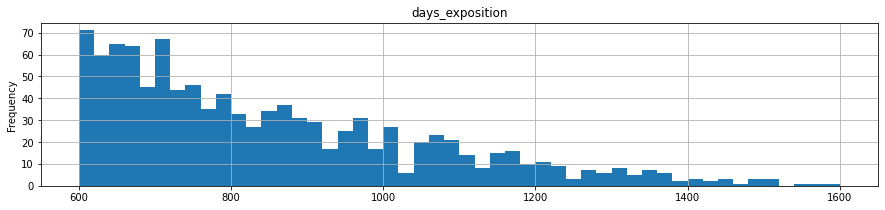

In [167]:
(data_without_tails_temp3['days_exposition'].plot(bins=50, title='days_exposition', 
                                            kind='hist', grid=True, figsize=(15,3), range=(600,1600)));

На гистограммах видно, что большинство значений срока экспозиции находится в интервале от 3 до 1400. Удалим из датафрейма значения менее 3 и более 1400 дней и проанализируем сколько значений датафрейма мы потеряем.

In [168]:
data_without_tails_temp4 = data_without_tails_temp3.query('3 <= days_exposition <= 1200')

In [169]:
data_without_tails_temp4 = data_without_tails_temp4[~data_without_tails_temp4['days_exposition'].isna()]

In [170]:
data_without_tails_temp3 = data_without_tails_temp3[~data_without_tails_temp3['days_exposition'].isna()]

In [171]:
percent_share(data_without_tails_temp4, data_without_tails_temp3)

0.5006556204553618

Потеряно почти 0.5 % данных. Для того чтобы строки с пропусками в столбце 'days_exposition' не влияли на расчет выше, они были отфильтрованы и полученные датасеты записаны во временные переменные, чтобы срез не записался в основные рабочe. переменную иdata_without_tails.

In [172]:
data_without_tails_temp3['days_exposition'].describe()

count    16778.000000
mean       191.502384
std        224.837782
min          1.000000
25%         42.000000
50%        110.000000
75%        251.000000
max       1580.000000
Name: days_exposition, dtype: float64

In [173]:
data_without_tails_temp4['days_exposition'].describe()

count    16694.000000
mean       186.010782
std        210.785992
min          3.000000
25%         42.000000
50%        109.000000
75%        246.000000
max       1200.000000
Name: days_exposition, dtype: float64

По выведенным статистическим показателям видно, что среднее значение, среднеквадратичное отклонение, а также медиана и третий квартиль уменьшились, увеличилось значение квартилей, незначительно увеличился первый квартиль. Исходя из значений квартилей можем сделать вывод что быстрвми продажами можно считать объявления со сроком экспозиции 42 дня и меньше (первый квартиль), типичный срок продажи составляет 109 дней и долгими продажами можно считать продажи со сроко экспонирования более 246 дней.

Рассмотрим изменение средней скорости продаж по годам 

In [174]:
(data_without_tails_temp4
    .pivot_table(index='year_publication', values='days_exposition', aggfunc=['mean', 'count'])
    .round(0)
)

,mean,count
,days_exposition,days_exposition
year_publication,,
2014,816.0,88
2015,606.0,898
2016,335.0,2305
2017,166.0,6611
2018,100.0,5922
2019,30.0,870


Исключим из анализа 2014 год, т.к. выборка по нему нерепрезентативна по количеству. На основании сводной таблицы выше, можно сделать вывод о том, что от года к году, средняя скорость продаж уменьшается. Однако изменения настолько существенные, что стоит проверить не влияет ли на среднюю скорость продаж, объявления, не снятые с продажи после сделки. Для этого проверим медианные значения скорости продаж по годам

In [175]:
(data_without_tails_temp4
    .pivot_table(index='year_publication', values='days_exposition', aggfunc=['median', 'count'])
    .round(0)
)

,median,count
,days_exposition,days_exposition
year_publication,,
2014,772.0,88
2015,558.0,898
2016,252.0,2305
2017,115.0,6611
2018,75.0,5922
2019,22.0,870


Тенденция по ускорению времени продаж год от года сохранилась, что обусловлено либо тем фактом, что со временем всё больше людей совершают покупку недвижимости в интернете, либо количество неснятых объявлений настолько большое, что влияет и на медиану, либо данное явление обусловлено "третьим фактором"

#### Анализ факторов, влияющих на стоимость объектов

*Определим факторы, которые больше всего влияют на общую  стоимость объекта*

*Оценим влияние общей площади на стоимость объекта*

<AxesSubplot:xlabel='total_area', ylabel='last_price'>

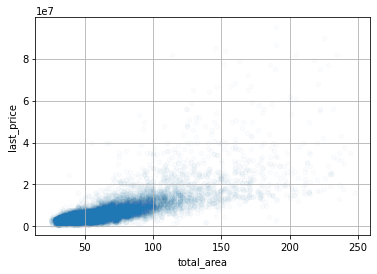

In [176]:
data_without_tails.plot(x='total_area', y='last_price', kind='scatter', alpha=0.02, grid=True)

<AxesSubplot:xlabel='total_area', ylabel='last_price'>

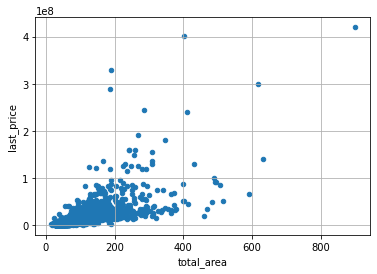

In [177]:
data_clear.plot(x='total_area', y='last_price', kind='scatter', grid=True)

In [178]:
data_without_tails['last_price'].corr(data_without_tails['total_area'])

0.7439582971636123

In [179]:
data_clear['last_price'].corr(data_clear['total_area'])

0.6903794770168175

Изучив диаграммы рассеяния выше, а также коэффициент корреляции Пирсона, може придти к выводу, что в целом стоимость и общая площадь объекта коррелируют между собой. Также, по гистограммам видно, что срезы датафрейма по отфильтрованным нами данным, избавили результат от выбросов, не потеряв при этом общей закономерности распределения значений датафрейма. 

*Оценим влияние жилой площади на стоимость объекта*

<AxesSubplot:xlabel='living_area', ylabel='last_price'>

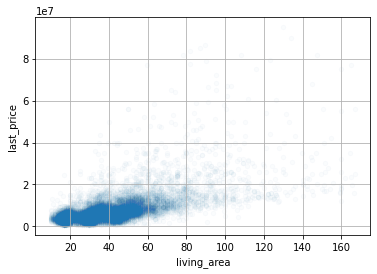

In [180]:
data_without_tails.plot(x='living_area', y='last_price', kind='scatter', alpha=0.02, grid=True)

<AxesSubplot:xlabel='living_area', ylabel='last_price'>

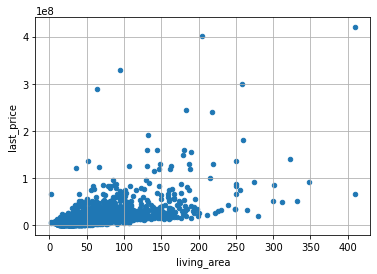

In [181]:
data_clear.plot(x='living_area', y='last_price', kind='scatter', grid=True)

In [182]:
data_without_tails['last_price'].corr(data_without_tails['living_area'])

0.6470706135745482

In [183]:
data_clear['last_price'].corr(data_clear['living_area'])

0.6020762025308001

Изучив диаграммы рассеяния выше, а также коэффициент корреляции Пирсона, може придти к выводу, что в целом стоимость и жилая площадь объекта коррелируют между собой, что закономерно, т.к. общая и жилая площадь - величины, зависящие друг от друга. Также, по гистограммам видно, что срезы датафрейма по отфильтрованным нами данным избавили результат от выбросов, не потеряв при этом общей закономерности распределения значений датафрейма.

*Оценим влияние площади кухни на стоимость объекта*

<AxesSubplot:xlabel='kitchen_area', ylabel='last_price'>

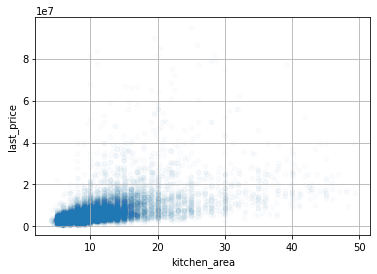

In [184]:
data_without_tails.plot(x='kitchen_area', y='last_price', kind='scatter', alpha=0.02, grid=True)

<AxesSubplot:xlabel='kitchen_area', ylabel='last_price'>

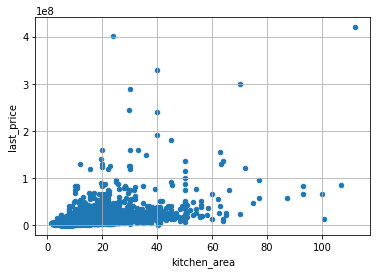

In [185]:
data_clear.plot(x='kitchen_area', y='last_price', kind='scatter', grid=True)

In [186]:
data_without_tails['last_price'].corr(data_without_tails['kitchen_area'])

0.5479417552999195

In [187]:
data_clear['last_price'].corr(data_clear['kitchen_area'])

0.5176064652281486

Изучив диаграммы рассеяния выше, а также коэффициент корреляции Пирсона, може придти к выводу, что в целом стоимость и площадь кухни коррелируют между собой, что закономерно, т.к. в большинстве случаев, чем больше кухня, тем больше общая площадь квартиры. Зависимость же между ценой и площадью, мы установили выше. Также, по гистограммам видно, что срезы датафрейма по отфильтрованным нами данным, избавили результат от выбросов, не потеряв при этом общей закономерности распределения значений датафрейма.

*Оценим влияние количества комнат на стоимость объекта*

<AxesSubplot:xlabel='rooms', ylabel='last_price'>

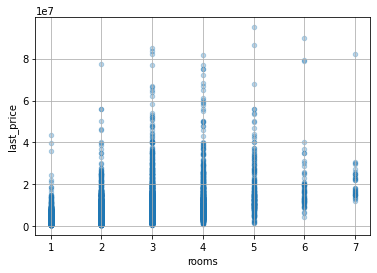

In [188]:
data_without_tails.plot(x='rooms', y='last_price', kind='scatter', alpha=0.3, grid=True)

По данным графикам сложно оценить распределение стоимости в зависимости от количества комнат, т.к. например, колонка пятикомнатных квартир имеет меньше значений в верхней части графика, однако она также имеет меньше значений в нижней части. Для дополнительного анализа, выведем сводные таблицы, определяющие среднее значение и медиану стоимости в зависимости от количества комнат объекта

In [189]:
data_without_tails.pivot_table(index='rooms', values='last_price')

,last_price
rooms,
1,3.853302e+06
2,5.543082e+06
3,7.812306e+06
4,1.186605e+07
5,1.688717e+07
6,1.985980e+07
7,2.174364e+07


In [190]:
data_without_tails.pivot_table(index='rooms', values='last_price', aggfunc=('median', 'count'))

,count,median
rooms,,
1,6903,3624000.0
2,6986,4800000.0
3,5167,6190000.0
4,1029,8990000.0
5,247,12990000.0
6,68,16245000.0
7,33,18000000.0


<AxesSubplot:xlabel='rooms', ylabel='last_price'>

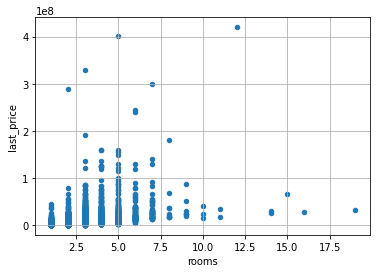

In [191]:
data_clear.plot(x='rooms', y='last_price', kind='scatter', grid=True)

In [192]:
data_without_tails['last_price'].corr(data_without_tails['rooms'])

0.45679448215330337

In [193]:
data_clear['last_price'].corr(data_clear['rooms'])

0.38978625580389425

Изучив диаграммы рассеяния выше, коэффициент корреляции Пирсона, а также среднее и медианное значение зависимости стоимости объекта, от количества комнат в нем, можно придти к выводу, что в целом стоимость и количество комнат объекта коррелируют между собой, Однако, стоит обратить внимание, что выборка по пятикомнатным квартирам нерепрезентативна по отношению к остальным выборкам. Также, по гистограммам видно, что срезы датафрейма по отфильтрованным нами данным, избавили результат от выбросов, не потеряв при этом общей закономерности распределения значений датафрейма.

*Оценим влияние типа этажа (первый, другой, последний) на стоимость объекта*

<AxesSubplot:xlabel='floor_type', ylabel='last_price'>

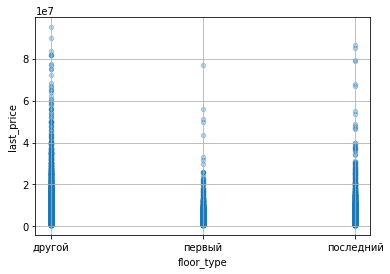

In [194]:
data_without_tails.plot(x='floor_type', y='last_price', kind='scatter', alpha=0.3, grid=True)

По данным графикам сложно оценить распределение стоимости в зависимости от типа этажа. Мы одназначно видим, что  квартиры расположенные на первом этаже проигрывают по стоимости остальным квартирам, однако сделать однозначный вывод по двум оставшимя типам затруднительно. Для дополнительного анализа, выведем сводные таблицы, определяющие среднее значение и медиану стоимости в зависимости от типа этажа объекта

In [195]:
data_without_tails.pivot_table(index='floor_type', values='last_price')

,last_price
floor_type,
другой,6.337717e+06
первый,4.691038e+06
последний,5.893823e+06


In [196]:
data_without_tails.pivot_table(index='floor_type', values='last_price', aggfunc=('median', 'count'))

,count,median
floor_type,,
другой,15073,4900000.0
первый,2478,3990000.0
последний,2882,4300000.0


<AxesSubplot:xlabel='floor_type', ylabel='last_price'>

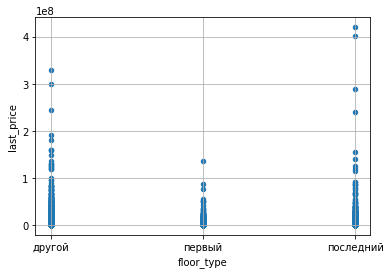

In [197]:
data_clear.plot(x='floor_type', y='last_price', kind='scatter', grid=True)

Изучив диаграммы рассеяния выше, а также среднее и медианное значение зависимости стоимости объекта от типа этажа, можно придти к выводу, что между данными величинами присутствует следующая зависимость: первые этажи стоят дешевле остальных типов этажей, последние этажи несколько дороже первых, но значительно уступают этажам категории "другие". Такое распределение стоимости обусловлено некоторыми негативными эксплуатационными характеристиками первых и последних этажей.  Также, по гистограммам видно, что срезы датафрейма по отфильтрованным нами данным, избавили результат от выбросов, не потеряв при этом общей закономерности распределения значений датафрейма.

*Оценим влияние дня недели публикации объявления на стоимость объекта*

<AxesSubplot:xlabel='weekday_publication', ylabel='last_price'>

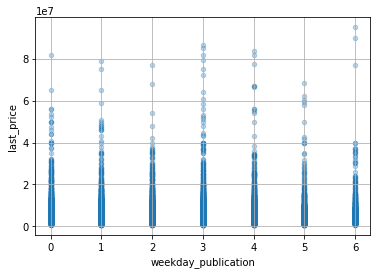

In [198]:
data_without_tails.plot(x='weekday_publication', y='last_price', kind='scatter', alpha=0.3, grid=True)

По данным графикам сложно оценить распределение стоимости в зависимости от дня недели публикации объявления.  Для дополнительного анализа, выведем сводные таблицы, определяющие среднее значение и медиану стоимости.

In [199]:
data_without_tails.pivot_table(index='weekday_publication', values='last_price')

,last_price
weekday_publication,
0,6.176407e+06
1,6.002711e+06
2,6.022214e+06
3,6.319593e+06
4,5.985888e+06
5,5.868151e+06
6,5.982903e+06


In [200]:
data_without_tails.pivot_table(index='weekday_publication', values='last_price', aggfunc=('median', 'count'))

,count,median
weekday_publication,,
0,3146,4745500.0
1,3636,4755467.5
2,3423,4750000.0
3,3715,4700000.0
4,3469,4600000.0
5,1624,4600000.0
6,1420,4580000.0


<AxesSubplot:xlabel='weekday_publication', ylabel='last_price'>

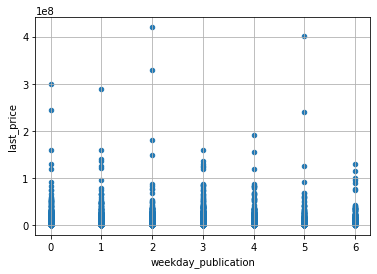

In [201]:
data_clear.plot(x='weekday_publication', y='last_price', kind='scatter', grid=True)

Изучив диаграммы рассеяния выше, а также среднее и медианное значение зависимости стоимости объекта от дня недели публикации объявления, можно придти к выводу, что объекты опубликованные в субботу и воскресенье имеют чуть меньшее среднее и медианное значение, относительно объявлений, опубликованных в будние дни. Определим на сколько стоимость объялений опубликованных в выходные дни, отличается от объявлений, опубликованных в будни.

Напишем функцию, которая отсортирует дни недели на будние дни (weekday) и выходные (weekend)

In [202]:
def weekday_type_name(row):
    if row['weekday_publication'] >=0 and row['weekday_publication'] <= 4:
        res = 'weekday'
    elif row['weekday_publication'] >=5 and row['weekday_publication'] <= 6:
        res = 'weekend'
    else:
        print('Некорректные данные!')
    return res

Добавим в датафрейм столбец weekday_type хранящий результат сортировки дней недели

In [203]:
data_without_tails['weekday_type'] = data_without_tails.apply(weekday_type_name, axis=1)

Создадим сводную таблицу, в которой определим среднюю цену объявдений опуюликованных в будние дни и в выходные

In [204]:
data_without_tails.pivot_table(index='weekday_type', values='last_price')

,last_price
weekday_type,
weekday,6.102318e+06
weekend,5.921682e+06


Исходя из данных из сводной таблицы выше, объявления опубликованные в будние дни, в среднем имеют стоимость объектов на 0,2 млн выше, чем объявления опубликованные в выходные

*Оценим влияние месяца публикации объявления на стоимость объекта*

<AxesSubplot:xlabel='month_publication', ylabel='last_price'>

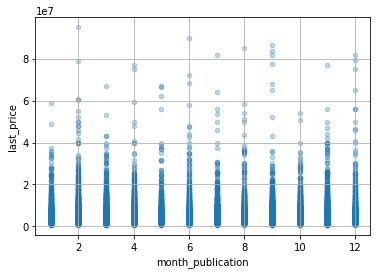

In [205]:
data_without_tails.plot(x='month_publication', y='last_price', kind='scatter', alpha=0.3, grid=True)

По данным графикам сложно оценить распределение стоимости в зависимости от месяца публикации объявления. Для дополнительного анализа, выведем сводные таблицы, определяющие среднее значение и медиану стоимости.

In [206]:
data_without_tails.pivot_table(index='month_publication', values='last_price')

,last_price
month_publication,
1,6.037132e+06
2,6.207456e+06
3,5.942301e+06
4,6.011514e+06
5,6.134960e+06
6,6.049579e+06
7,6.028497e+06
8,6.096736e+06
9,6.212177e+06


In [207]:
data_without_tails.pivot_table(index='month_publication', values='last_price', aggfunc=('median', 'count'))

,count,median
month_publication,,
1,1220,4600000.0
2,2249,4749000.0
3,2217,4700000.0
4,2078,4850000.0
5,1111,4550000.0
6,1524,4500000.0
7,1438,4650000.0
8,1510,4610000.0
9,1779,4730000.0


<AxesSubplot:xlabel='month_publication', ylabel='last_price'>

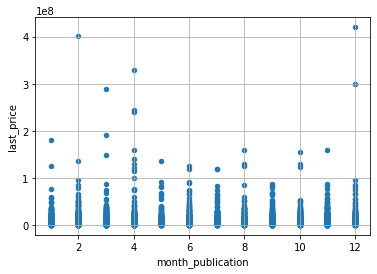

In [208]:
data_clear.plot(x='month_publication', y='last_price', kind='scatter', grid=True)

Изучив диаграммы рассеяния выше, а также среднее и медианное значение зависимости стоимости объекта от месяца публикации объявления, можно придти к выводу, что объявление опубликованные в июне, имеют чуть меньшее среднее и медианное значение , относительно объявлений, опубликованных в другие месяцы. Это может быть связано с желанием продать квартиру до начала летнего отпуска и предоставлением продавцами соответствующей скидки, либо быть влиянием некоторого "третьего" фактора. Имеющихся у нас данных недостаточно для обоснованного ответа на данный вопрос. Также, по гистограммам видно, что срезы датафрейма по отфильтрованным нами данным, избавили результат от выбросов, не потеряв при этом общей закономерности распределения значений датафрейма.

*Оценим влияние года публикации объявления на стоимость объекта*

<AxesSubplot:xlabel='year_publication', ylabel='last_price'>

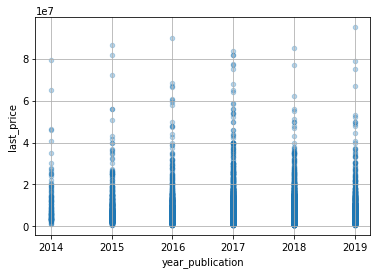

In [209]:
data_without_tails.plot(x='year_publication', y='last_price', kind='scatter', alpha=0.3, grid=True)

По данным графикам сложно оценить распределение стоимости в зависимости от года публикации объявления. Для дополнительного анализа, выведем сводные таблицы, определяющие среднее значение и медиану стоимости.

In [210]:
(data_without_tails
    .pivot_table(index='year_publication', values='last_price')
    .round(2)
)

,last_price
year_publication,
2014,11687246.94
2015,7254261.17
2016,6200833.13
2017,5960835.96
2018,5769148.94
2019,6391009.87


In [211]:
data_without_tails.pivot_table(index='year_publication', values='last_price', aggfunc=('median'))

,last_price
year_publication,
2014,7640000.0
2015,5200000.0
2016,4590000.0
2017,4500000.0
2018,4650000.0
2019,5100000.0


In [212]:
(data_clear
    .pivot_table(index='year_publication', values='last_price')
    .round(2)
)

,last_price
year_publication,
2014,12113748.96
2015,8373178.67
2016,6697453.03
2017,6489887.11
2018,6033736.78
2019,6715454.59


In [213]:
data_clear.pivot_table(index='year_publication', values='last_price', aggfunc=('median'))

,last_price
year_publication,
2014,7700000.0
2015,5267500.0
2016,4600000.0
2017,4550000.0
2018,4650000.0
2019,5100000.0


Проанализируем зависимость изменения среднего значения общей площади и стоимости в зависимости от года публикации объявления:

In [214]:
(data_without_tails
    .pivot_table(index='year_publication', values='total_area', aggfunc='count')
    .round(2)
)

,total_area
year_publication,
2014,124
2015,1020
2016,2449
2017,7218
2018,7100
2019,2522


Проанализируем зависимость изменения среднего значения общей площади, в зависимости от года публикации объявления:

In [215]:
data_price_per_area = (pd.pivot_table(data_without_tails, index='year_publication', 
                values=['last_price','total_area'], aggfunc={'last_price':[np.mean, len],'total_area':np.mean})).round(2)
data_price_per_area['price_per_area'] = \
(data_price_per_area['last_price','mean']/data_price_per_area['total_area', 'mean']).round(2)
data_price_per_area

last_price              total_area price_per_area
                        len         mean       mean               
year_publication                                                  
2014                  124.0  11687246.94      83.94      139233.34
2015                 1020.0   7254261.17      67.47      107518.32
2016                 2449.0   6200833.13      61.13      101436.83
2017                 7218.0   5960835.96      59.05      100945.57
2018                 7100.0   5769148.94      57.27      100735.97
2019                 2522.0   6391009.87      57.76      110647.68

Изучив диаграммы рассеяния выше, а также среднее и медианное значение зависимости стоимости объекта от года публикации объявления, можно придти к выводу, что объекты опубликованные в 2014 и 2015 годах имеют большее среднее и медианное значение стоимости, по сравнению с последующими годами, что нетипично, ведь как правило стоимость жилья со временем растет. ПРовели дополнительный анализ, создав сводную таблицу со значениями "общая плошадь", "стоимость", "общая плошадь/стоимость", "количество объявлений. Исходя из количества объявлений опубликованных по годам, 2014 год необходимо исключить из анализа , в связи с нерепрезентативностью выборки, по количеству значений. В промежуток с 2015-го по 2018 год наблюдается снижение средней стоимости объекта, однако стоит обратить внимание, что и средняя площадь в этом промежутке уменьшалась от года, к году. Если мы посмотрим на отношение средней общей площади к средней общей стоимости (price_per_area) в промежутке с с 2016-го по 2018 год, то увидим что в данном промежутке средняя цена за средний квадрат была в районе 101 000 руб/м2, т.е. практически не изменялась. Повышенная стоимость price_per_area в 2015-м могла быть связана с нестабильным курсом валюты в том году и как следствие ажиотажным спросом на недвижимость, с соответствующим повышением цен.  Также, на распределение стоимости мог повлиять тот факт, что в 2014 и 2015 годах еще не было развито массовое распространение объявлений в интернете и возможно объявления размещали владельцы более дорогой недвижимости. Результаты 2019 года показывают рост средней стоимости объекта, практически без увеличения средней стоимости объекта, что скорее всего обусловлено ростом цен на рынке недвижимости в этом году, т.к.изменения лежат в пределах +10%

#### Топ 10 населенных пунктов по количеству объявлений.

*Определим среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений. а также определим населённые пункты с самой высокой и низкой стоимостью квадратного метра.*

*Определим среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений*

In [216]:
data_without_tails_top10 = (
    data_without_tails
        .pivot_table(index='locality_name', values='cost_square_meter', aggfunc=('mean', 'count'))
        .round(2)
        .sort_values(by='count', ascending=False)
        .head(10)
    )
data_without_tails_top10

,count,mean
locality_name,,
Санкт-Петербург,13754,112118.13
поселок Мурино,416,85127.25
поселок Шушары,389,78390.22
Кудрово,369,95150.93
Всеволожск,348,69200.75
Пушкин,330,103068.42
Колпино,321,75129.85
поселок Парголово,288,90756.00
Гатчина,267,68787.04


*Определим населённый пункт с самой высокой стоимостью квадратного метра*

In [217]:
(data_without_tails_top10
    .sort_values(by='mean', ascending=False)
    .head(1)
)

,count,mean
locality_name,,
Санкт-Петербург,13754,112118.13


*Определим населённый пункт с самой низкой стоимостью квадратного метра*

In [218]:
(data_without_tails_top10
    .sort_values(by='mean')
    .head(1)
)

,count,mean
locality_name,,
Гатчина,267,68787.04


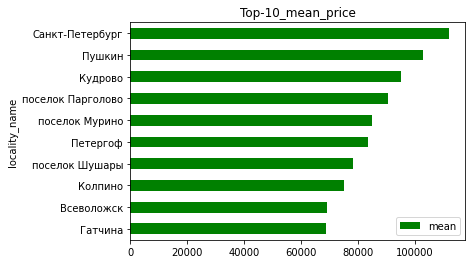

In [219]:
(data_without_tails_top10
    .sort_values(by='mean')
    .plot.barh(y='mean', title='Top-10_mean_price', color='green')
); 

#### Анализ средней стоимости объектов в г. Санкт-Петербург, в зависимости от расстояния от центра

*Вычислим среднюю стоимость объекта для Санкт-Петербурга, на разном удалении от центра. Цену выведем для каждого километра расстояния: в одном километре от центра, в двух и так далее*

In [220]:
(data_without_tails
        .query('locality_name == "Санкт-Петербург"')
        .pivot_table(index='city_centers_nearest_kilometer', values='last_price', aggfunc=('mean', 'count'))
        .head(30)
        .round(2)
)

,count,mean
city_centers_nearest_kilometer,,
0.0,20,21944081.40
1.0,159,14809427.67
2.0,263,14590669.51
3.0,304,10139001.31
4.0,594,10995347.88
5.0,767,11444324.79
6.0,488,12005566.12
7.0,364,13022531.39
8.0,518,9076424.57


<AxesSubplot:xlabel='city_centers_nearest_kilometer'>

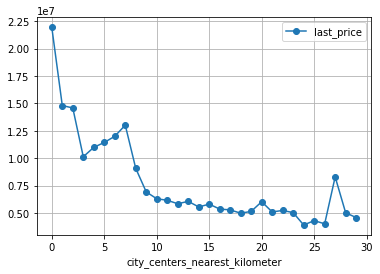

In [221]:
(data_without_tails
        .query('locality_name == "Санкт-Петербург"')
        .pivot_table(index='city_centers_nearest_kilometer', values='last_price', aggfunc=('mean'))
        .plot(style='o-', grid=True)
)

В целом, с увеличением расстояния от центра Санкт-Петербурга на каждый километр, средняя стоимость объявлений понижается, на графике выше имеется сильный всплеск на значении 27 км от центра, однако как видно из сводной таблицы выше, у нас имеется всего два объявления по данному значению, так что данный всплеск можем интерпретировать как выброс, т.к. количество объявлений нерепрезентативно.

Рассмотрим количество продаж различных типов квартир ("первый", "другой", "последний") а также их  распределение в процентах, на каждом километре от центра, чтобы проанализировать, влияет ли данный фактор на неравномерное распределение средней стоимости на отрезке с 0-го по 10-й километры

In [222]:
df2=(data_without_tails
    .query('locality_name == "Санкт-Петербург"')
    .pivot_table(index='city_centers_nearest_kilometer', values='floor_type', aggfunc='count')
    .round(2)
)

In [223]:
df1=(data_without_tails
    .query('locality_name == "Санкт-Петербург"')
    .pivot_table(index='city_centers_nearest_kilometer', columns='floor_type', aggfunc={'floor_type': len}, fill_value=0)
    .round(2)
)

floor_type_count = df1.merge(df2, on='city_centers_nearest_kilometer') 


floor_type_count['%первый'] = floor_type_count['floor_type', 'первый'] / floor_type_count['floor_type']*100
floor_type_count['%другой'] = floor_type_count['floor_type', 'другой'] / floor_type_count['floor_type']*100
floor_type_count['%последний'] = floor_type_count['floor_type', 'последний'] / floor_type_count['floor_type']*100
floor_type_count.round(2)

/opt/conda/lib/python3.9/site-packages/pandas/core/reshape/merge.py:648: UserWarning: merging between different levels can give an unintended result (2 levels on the left,1 on the right)
  warnings.warn(msg, UserWarning)


,"(floor_type, другой)","(floor_type, первый)","(floor_type, последний)",floor_type,%первый,%другой,%последний
city_centers_nearest_kilometer,,,,,,,
0.0,14,2,4,20,10.00,70.00,20.00
1.0,98,22,39,159,13.84,61.64,24.53
2.0,155,39,69,263,14.83,58.94,26.24
3.0,184,48,72,304,15.79,60.53,23.68
4.0,429,66,99,594,11.11,72.22,16.67
5.0,591,65,111,767,8.47,77.05,14.47
6.0,360,54,74,488,11.07,73.77,15.16
7.0,285,26,53,364,7.14,78.30,14.56
8.0,409,47,62,518,9.07,78.96,11.97


<AxesSubplot:xlabel='city_centers_nearest_kilometer'>

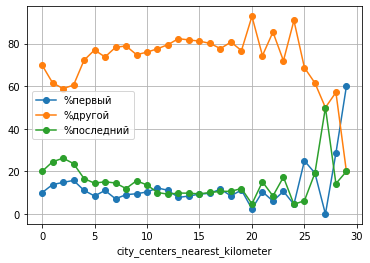

In [224]:
(floor_type_count
        .plot(y=['%первый', '%другой', '%последний'], style='o-', grid=True)
                 )

Проанализировав полученные данные, можно сказать что наблюдается взамосвязь между резким падением на графике распределения средней стоимости по километрам от центра города в дипазоне 0 и 3 км и последующим резким подъемом в интервале 3 и 5 км  от количества продаж квартир типа этажа "другой". Как видно на графике выше, а также в сводной таблице распределения типов квартир, резкое увеличение графика стоимости в интервале с третьего по пятый километр, совпадает с увеличением процента продаж квартир типа "другой" на данном интервале. Ранее мы выяснили, что квартиры типа "другой" продаются дороже остальных типов этажей и соответсвенно увеличение доли таких квартир в продажах, может привести к увеличению средней стоимости.
<br> С другой стороны, на интервале с 5-го по 7-й километр средняя стоимость квартир продолжает расти, однако доля квартир типа "другой" на этом интервале не растет стль резко, а на отметке 6-го километра даже падает. 

**Вывод:** В рамках исследовательского анализа нами были построены и проанализированы гистограммы по значениям
общая площадь;
жилая площадь;
площадь кухни;
цена объекта;
количество комнат;
высота потолков;
тип этажа квартиры («первый», «последний», «другой»);
общее количество этажей в доме;
расстояние до центра города в метрах;
расстояние до ближайшего парка. 
Определены и исключены выбросы, способные повлиять на дальнейший анализ. Проведен анализ основных статистических показателей до и после фильтрации датафрейма. 
Определены среднее и медианное значение срока продажи квартир, выявлены аномалии в продажах на 45-й и 60-й день продаж.
Определены сроки быстрых (42 дня), типичных (109 дней) и долгих продаж (246 дней).
Построены диаграммы рассеивания, описывающие зависимость влияния 
общей площади;
жилой площади;
площади кухни;
количества комнат;
этажа, на котором расположена квартира (первый, последний, другой);
даты размещения (день недели, месяц, год) 
на стоимость объекта.
Посчитаны средние цены одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений Определены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
Вычислена средняя стоимость объектов на разном удалении от центра г. Санкт-Петербург. Определена средняя цена квартир в одном километре от центра, в двух и так далее. Построен график изменения средней цены для каждого километра от центра Петербурга.

### Общий вывод

**Общий вывод:**
По результатам проведенного исследования объявлений по продаже недвижимости в г.Санкт-Петербурге и населенных пунктах Ленинградской области, была выполнена предобработка данных - обработаны пропуски, явные и неявные дубликаты в данных, а также обработка дубликатов по подмножеству основных характеристик объектов. На основании имеющихся данных, рассчитаны и добавлены в датафрейм столбцы с новыми параметрами, необходимыми для дальнейшего анализа. По основным параметрам объявлений построены гистограммы, определены и отброшены "выбросы" данных, мешающие дальнейшему исследованию. Определены среднее (177 дней) и медианное (94 дня) значение срока продажи квартир, а также сроки быстрых (менее 42 дней), типичных (109 дней) и долгих продаж (более 246 дней) В районе 45 и 60  дней имелись всплески, которые могут быть вызваны "третьим фактором",  т.к. данные значения соответствуют ровно 1,5; 2  месяцам и не похожи на случайное распределение. Во избежания искажения резултатов анализа средней скорости продаж, данные по этим дням были исключены из исследования.  Проанализирована корреляция стоимости объектов от следующих параметров: общей площади - положительная, жилой площади - положительная, площади кухни - положительная, количества комнат - положительная, типа этажа (первый, другой, последний) - первый и последний этажи экспонируются дешевле этажей категории "другие", даты размещения объявлений: по дню недели - есть взаимосвязь между более дешевыми объявлениями размещенными в выходные (в среднем объявления размещенные в выходные дешевле на 0,2 млн руб), по месяцу - наиболее дешевые объявления были размещены в июне, по году: объявления опубликованные в 2014 году исключены из анализа, в связи с нерепрезентативностью выборки,с нерепрезентативностью выборки, по количеству значений. В промежуток с 2015-го по 2018 год наблюдается снижение средней стоимости объекта, однако стоит обратить внимание, что и средняя площадь в этом промежутке уменьшалась от года, к году.  Отношение средней общей площади к средней общей стоимости  в промежутке с с 2016-го по 2018 год практически не изменялась. Повышенная стоимость в 2015-м могла быть связана с нестабильным курсом валюты в том году и как следствие ажиотажным спросом на недвижимость, с соответствующим повышением цен. Также, на распределение стоимости мог повлиять тот факт, что в 2014 и 2015 годах еще не было развито массовое распространение объявлений в интернете и возможно объявления размещали владельцы более дорогой недвижимости. Результаты 2019 года показывают рост средней стоимости объекта, практически без увеличения средней стоимости объекта, что скорее всего обусловлено ростом цен на рынке недвижимости в этом году, т.к.изменения лежат в пределах +10%. 
Основными параметрами влияющими на стоимость являются: общая площадь, жилая площадь, площадь кухни, количества комнат и тип этажа на котором расположена квартира.
Посчитаны средние цены одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений: Санкт-Петербург, поселок Мурино, поселок Шушары, Всеволожск, Пушкин, Колпино, поселок Парголово, Гатчина, деревня Кудрово, Выборг.
Определены населённые пункты с самой высокой (Санкт-Петербрг - 108665.91 руб.) и низкой (Выборг - 57883.77 руб.) стоимостью квадратного метра.
Вычислена средняя стоимость объектов на разном удалении от центра г. Санкт-Петербург. Определена средняя цена квартир в одном километре от центра, в двух и так далее. Построен график изменения средней цены для каждого километра от центра Петербурга, проанализированы аномальные всплески в интервале с 0-го по 10-й километры и их завиимость от количества продаваемых квартир различных типов этажей("первый", "другой", "последний").  В целом, с увеличением расстояния от центра Санкт-Петербурга на каждый километр, средняя стоимость объявлений понижается.

### Бонус

In [225]:
# check
import seaborn as sns
import matplotlib.pyplot as plt

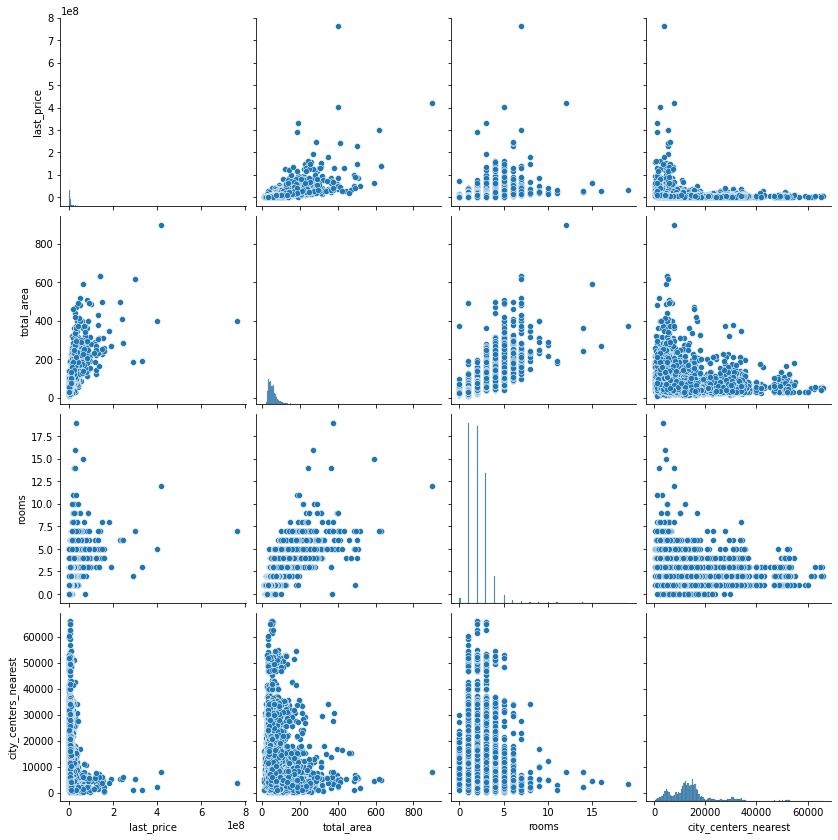

In [226]:
# check
sns.pairplot(data[['last_price', 'total_area', 'rooms', 'city_centers_nearest']])
plt.gcf().set_size_inches(12,12);


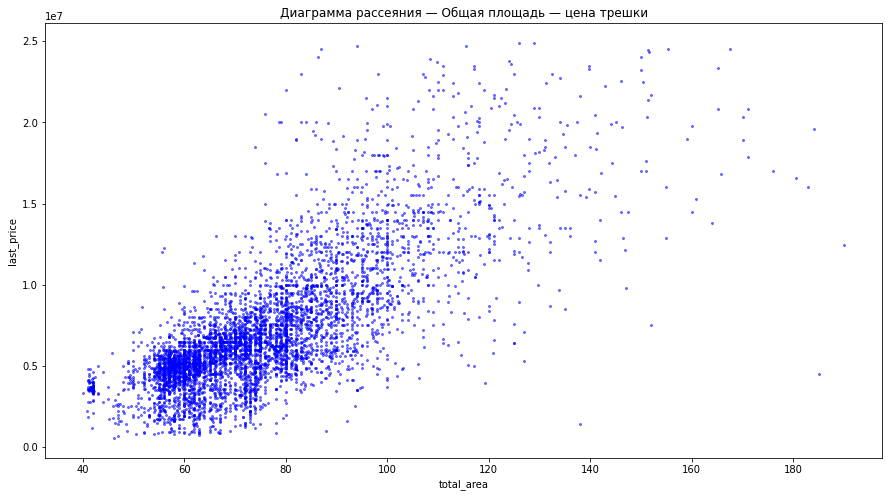

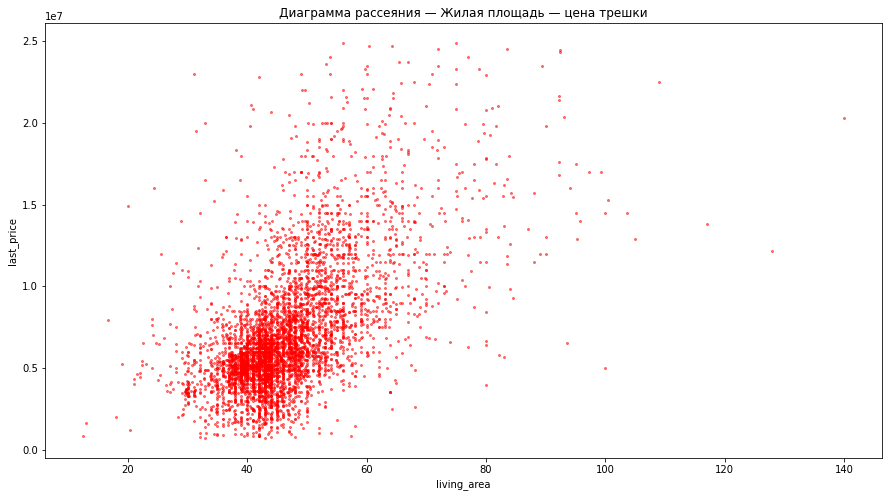

In [227]:
# check
data[data['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(kind='scatter',
        y='last_price' , x='total_area', alpha=0.5, subplots=True, figsize=(15,8), c = 'b', s = 4)
plt.title('Диаграмма рассеяния — Общая площадь — цена трешки')


data[data['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(kind='scatter', 
        y='last_price' , x='living_area', alpha=0.5, figsize=(15,8), c = 'r', s = 4)
plt.title('Диаграмма рассеяния — Жилая площадь — цена трешки');